# Section 1: Environment & Helpers

In [ ]:
!pip install --quiet "rpy2>=3.5,<3.6" statsmodels

In [ ]:
"""
REnvironment: a single class that manages an R environment for rpy2
workflows. Handles the boilerplate that recurs when using rpy2:
  * Optional Google Drive mounting (for persistent package caching)
  * R library path configuration
  * Conditional R package installation (skip if already cached)
  * R package loading via importr
  * Inspection of environment state
  * An escape hatch (run_r) for arbitrary R code
"""

import logging
import os
import warnings
from typing import Dict, Iterable, List, Optional

import rpy2.robjects as ro
from rpy2.rinterface_lib.callbacks import logger as _rpy2_logger
from rpy2.robjects.packages import (
    PackageNotInstalledError,
    importr,
    isinstalled,
)
from rpy2.robjects.vectors import StrVector


_DEFAULT_CRAN_MIRROR = "https://cloud.r-project.org"


class REnvironmentError(RuntimeError):
    """Raised when R environment setup fails in an unrecoverable way."""


class REnvironment:
    """
    Manage an R environment for rpy2-based workflows, with optional
    Drive-based package caching for Google Colab.

    Parameters
    ----------
    cache_dir : str, optional
        Directory to use as a persistent R library. If provided, this
        directory is prepended to .libPaths() and is the default install
        target, so packages installed once persist across sessions
        (when the directory itself persists, e.g. on Drive).
        If None, R's default user library is used (ephemeral on Colab;
        reinstalls every session).
    cran_mirror : str, default "https://cloud.r-project.org"
    quiet : bool, default True
        If True, suppress R install chatter and lower the rpy2 logger
        to ERROR. Set to False when debugging install issues.

    Notes
    -----
    No R interaction happens in __init__. The class is purely a
    configuration container until setup() (or one of the lower-level
    methods) is called.
    """

    def __init__(
        self,
        cache_dir: Optional[str] = None,
        cran_mirror: str = _DEFAULT_CRAN_MIRROR,
        quiet: bool = True,
    ):
        self.cache_dir = cache_dir
        self.cran_mirror = cran_mirror
        self.quiet = quiet

        self._loaded_packages: Dict[str, object] = {}
        self._libpath_set = False
        self._drive_mounted = False

        if quiet:
            _rpy2_logger.setLevel(logging.ERROR)

    # ------------------------------------------------------------------ #
    # Convenience: do everything in one call
    # ------------------------------------------------------------------ #
    def setup(
        self,
        packages: Iterable[str],
        mount_drive: bool = False,
    ) -> "REnvironment":
        """Run the full setup pipeline. Returns self for chaining."""
        if mount_drive:
            self.mount_drive()
        if self.cache_dir is not None:
            self._ensure_cache_dir_exists()
            self.set_libpath()
        self.install(packages)
        self.load(packages)
        return self

    # ------------------------------------------------------------------ #
    # Drive mounting (Colab only)
    # ------------------------------------------------------------------ #
    def mount_drive(self, mountpoint: str = "/content/drive") -> None:
        """Mount Google Drive in a Colab session."""
        try:
            from google.colab import drive  # type: ignore
        except ImportError as e:
            raise REnvironmentError(
                "mount_drive() is only available in Google Colab. "
                "Either remove the mount_drive=True argument, or set "
                "cache_dir to a local path that already exists."
            ) from e

        drive.mount(mountpoint)
        self._drive_mounted = True

    # ------------------------------------------------------------------ #
    # Library path configuration
    # ------------------------------------------------------------------ #
    def _ensure_cache_dir_exists(self) -> None:
        if self.cache_dir is None:
            return
        os.makedirs(self.cache_dir, exist_ok=True)

    def set_libpath(self) -> List[str]:
        """Prepend cache_dir to R's .libPaths()."""
        if self.cache_dir is None:
            raise REnvironmentError(
                "set_libpath() requires cache_dir to be set."
            )
        self._ensure_cache_dir_exists()

        # We pass cache_dir as a parameterized R string to avoid quoting
        # bugs on paths containing spaces (e.g. "My Drive"). Use a dotted
        # name so it's hidden from ls() and unlikely to clash with user vars.
        ro.globalenv[".rsk_cache_dir"] = self.cache_dir
        ro.r(".libPaths(c(.rsk_cache_dir, .libPaths()))")
        self._libpath_set = True
        return self.lib_paths

    @property
    def lib_paths(self) -> List[str]:
        """Current value of R's .libPaths() as a Python list."""
        return list(ro.r(".libPaths()"))

    # ------------------------------------------------------------------ #
    # Install / inspect
    # ------------------------------------------------------------------ #
    def is_installed(self, package: str) -> bool:
        return bool(isinstalled(package))

    def installed_packages(self) -> List[str]:
        return list(ro.r('installed.packages()[, "Package"]'))

    def install(self, packages: Iterable[str]) -> List[str]:
        """
        Install any of `packages` that aren't already installed. Skip
        already-installed packages. Returns the list actually installed.
        """
        packages = list(packages)
        missing = [p for p in packages if not self.is_installed(p)]

        if not missing:
            return []

        utils = importr("utils")

        kwargs = dict(repos=self.cran_mirror, quiet=self.quiet)
        if self.cache_dir is not None:
            kwargs["lib"] = self.cache_dir

        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            utils.install_packages(StrVector(missing), **kwargs)

        # R's install.packages does not raise on failure -- check ourselves
        still_missing = [p for p in missing if not self.is_installed(p)]
        if still_missing:
            raise REnvironmentError(
                f"Failed to install R packages: {still_missing}. "
                f"Check network access and that the CRAN mirror "
                f"({self.cran_mirror}) is reachable. Re-run with "
                f"quiet=False to see R's install diagnostics."
            )
        return missing

    # ------------------------------------------------------------------ #
    # Load
    # ------------------------------------------------------------------ #
    def load(self, packages: Iterable[str]) -> Dict[str, object]:
        """importr() each package and stash the proxy on this instance."""
        packages = list(packages)
        loaded: Dict[str, object] = {}
        for pkg in packages:
            if pkg in self._loaded_packages:
                loaded[pkg] = self._loaded_packages[pkg]
                continue
            try:
                proxy = importr(pkg)
            except PackageNotInstalledError as e:
                raise REnvironmentError(
                    f"Package '{pkg}' is not installed. Call "
                    f"env.install(['{pkg}']) first, or use "
                    f"env.setup([..., '{pkg}']) to install and load "
                    f"in one step."
                ) from e
            self._loaded_packages[pkg] = proxy
            loaded[pkg] = proxy
        return loaded

    @property
    def loaded_packages(self) -> List[str]:
        return list(self._loaded_packages.keys())

    def __getitem__(self, package: str) -> object:
        if package not in self._loaded_packages:
            raise KeyError(
                f"Package '{package}' has not been loaded. "
                f"Call env.load(['{package}']) first."
            )
        return self._loaded_packages[package]

    def __contains__(self, package: str) -> bool:
        return package in self._loaded_packages

    # ------------------------------------------------------------------ #
    # Escape hatch
    # ------------------------------------------------------------------ #
    def run_r(self, code: str):
        """Execute arbitrary R code and return the result."""
        return ro.r(code)

    def __repr__(self) -> str:
        return (
            f"REnvironment(cache_dir={self.cache_dir!r}, "
            f"cran_mirror={self.cran_mirror!r}, "
            f"loaded={self.loaded_packages})"
        )

In [ ]:
# --- Option A: ephemeral, runs every session (default) ---
env = REnvironment(quiet=True)

# --- Option B: persistent across sessions via Drive ---
# env = REnvironment(
#     cache_dir="/content/drive/My Drive/R_libs",
#     quiet=True,
# )

R_PACKAGES = [
    "MASS",          # negative binomial GLM, LDA
    "randomForest",  # RF classifier and regressor
    "e1071",         # SVM, naive Bayes
    "gbm",           # gradient boosting (classifier and regressor)
    "forecast",      # auto.arima, ets, tbats
    "glmmTMB",       # mixed-effects models
    "DHARMa",        # residual diagnostics
]

# For Option B above, also pass mount_drive=True
env.setup(packages=R_PACKAGES, mount_drive=False)

print()
print(f"Loaded packages: {env.loaded_packages}")
print(f"R library paths: {env.lib_paths}")


Loaded packages: ['MASS', 'randomForest', 'e1071', 'gbm', 'forecast', 'glmmTMB', 'DHARMa']
R library paths: ['/usr/local/lib/R/site-library', '/usr/lib/R/site-library', '/usr/lib/R/library']


In [ ]:
# Confirm R is reachable and report R + key package versions
print("R version:")
print(env.run_r("R.version.string")[0])
print()

print("Package versions:")
for pkg in R_PACKAGES:
    version = env.run_r(f'as.character(packageVersion("{pkg}"))')[0]
    print(f"  {pkg:15s} {version}")

R version:
R version 4.6.0 (2026-04-24)

Package versions:
  MASS            7.3.65
  randomForest    4.7.1.2
  e1071           1.7.17
  gbm             2.2.3
  forecast        9.0.2
  glmmTMB         1.1.14
  DHARMa          0.4.7


In [ ]:
import re
import numpy as np
import pandas as pd
import rpy2.robjects as ro
from rpy2.robjects import default_converter, pandas2ri
from rpy2.robjects.conversion import localconverter

# ---------------------------------------------------------------------- #
# R sentinel names shared across modules
# ---------------------------------------------------------------------- #
# Used by GLMs, classifiers, regressors, forecasters, and mixed models.
# Coexistence works because every method rebinds globalenv[R_MODEL] to
# self.r_object_ before any R call. The other slots are similarly
# rebound from per-instance Python state at use time.

# Universal: the fitted R model goes here, every class
R_MODEL       = ".rsk_model"

# GLMs only: the null-only model for McFadden pseudo-R^2
R_NULL_MODEL  = ".rsk_null_model"

# GLMs and classifiers/regressors: training and prediction frames,
# plus the response column name within each
R_TRAIN_DF    = ".rsk_train_df"
R_PREDICT_DF  = ".rsk_predict_df"
R_Y_COLNAME   = "rsk_y"

# Forecasters (Section 4): time series and exogenous regressor slots
R_TRAIN_TS     = ".rsk_train_ts"
R_FORECAST_OBJ = ".rsk_forecast"
R_XREG         = ".rsk_xreg"
R_XREG_FUTURE  = ".rsk_xreg_future"

# Mixed models (Section 5): full DataFrame including grouping columns
# (distinct from R_TRAIN_DF since GLMMs don't have a (X, y) split)
R_GLMM_DATA    = ".rsk_glmm_data"
R_GLMM_NEWDATA = ".rsk_glmm_newdata"


# ---------------------------------------------------------------------- #
# Numpy <-> R conversion safety
# ---------------------------------------------------------------------- #
def r_to_numpy(r_obj) -> np.ndarray:
    """
    Convert an R vector or matrix to a Python-owned numpy array.

    CRITICAL: np.asarray() on an rpy2 vector returns a *view* into R's
    managed memory. When R reuses that memory (which happens constantly
    across model fits and predicts), the view's contents silently
    change -- the user's array mutates from underneath them.

    This helper forces a copy so the returned array's lifetime is
    independent of R's. Always use this instead of np.asarray() on
    rpy2 outputs that are returned to the user or stored on self.
    """
    return np.array(r_obj, copy=True)


def r_to_dataframe(r_name: str) -> pd.DataFrame:
    """
    Convert an R object in globalenv (by name) to a pandas DataFrame.

    Public utility for users writing custom R code via the .run_r()
    escape hatch on any model class -- e.g. extracting a tabular result
    that R produced and you want to inspect in pandas.

    The model classes themselves don't use this helper internally
    (they pull matrices/vectors via r_to_numpy plus rownames/colnames),
    but it is exported for user convenience.

    Example
    -------
        >>> model.run_r('.my_table <- as.data.frame(model$some_table)')
        >>> df = r_to_dataframe('.my_table')

    Parameters
    ----------
    r_name : str
        The name of the R object in globalenv to convert.

    Returns
    -------
    pandas.DataFrame
    """
    ro.r(f".rsk_df_tmp <- as.data.frame({r_name})")
    with localconverter(default_converter + pandas2ri.converter):
        return ro.conversion.rpy2py(ro.globalenv[".rsk_df_tmp"])


# ---------------------------------------------------------------------- #
# R identifier handling for formulas
# ---------------------------------------------------------------------- #
# Regex matching R-syntactic names: starts with a letter or with a dot
# followed by a letter or dot/underscore. Anything else needs backtick-
# quoting in R formulas. This is what trips up auto-built formulas when
# DataFrame columns have spaces or parentheses (e.g. iris's
# "sepal length (cm)").
R_VALID_IDENT = re.compile(r"^(?:[A-Za-z]|\.[A-Za-z_.])[A-Za-z0-9._]*$")


def r_quote_name(name: str) -> str:
    """
    Wrap an R identifier in backticks if it isn't a valid R name.

    Pandas DataFrame columns frequently contain spaces, parentheses,
    hyphens, and other characters that R formulas reject unless
    backtick-quoted.
    """
    if R_VALID_IDENT.match(name):
        return name
    if name.startswith("`") and name.endswith("`"):
        return name  # don't double-wrap
    return f"`{name}`"


def r_unquote_name(name: str) -> str:
    """Inverse of r_quote_name: strip backticks if present."""
    if name.startswith("`") and name.endswith("`"):
        return name[1:-1]
    return name


print("Sentinel constants defined:")
print(f"  R_MODEL          = {R_MODEL!r}")
print(f"  R_NULL_MODEL     = {R_NULL_MODEL!r}")
print(f"  R_TRAIN_DF       = {R_TRAIN_DF!r}")
print(f"  R_PREDICT_DF     = {R_PREDICT_DF!r}")
print(f"  R_Y_COLNAME      = {R_Y_COLNAME!r}")
print(f"  R_TRAIN_TS       = {R_TRAIN_TS!r}")
print(f"  R_FORECAST_OBJ   = {R_FORECAST_OBJ!r}")
print(f"  R_XREG           = {R_XREG!r}")
print(f"  R_XREG_FUTURE    = {R_XREG_FUTURE!r}")
print(f"  R_GLMM_DATA      = {R_GLMM_DATA!r}")
print(f"  R_GLMM_NEWDATA   = {R_GLMM_NEWDATA!r}")

Sentinel constants defined:
  R_MODEL          = '.rsk_model'
  R_NULL_MODEL     = '.rsk_null_model'
  R_TRAIN_DF       = '.rsk_train_df'
  R_PREDICT_DF     = '.rsk_predict_df'
  R_Y_COLNAME      = 'rsk_y'
  R_TRAIN_TS       = '.rsk_train_ts'
  R_FORECAST_OBJ   = '.rsk_forecast'
  R_XREG           = '.rsk_xreg'
  R_XREG_FUTURE    = '.rsk_xreg_future'
  R_GLMM_DATA      = '.rsk_glmm_data'
  R_GLMM_NEWDATA   = '.rsk_glmm_newdata'


In [ ]:
# Smoke test: round-trip a small numeric vector and a small matrix
# through R and back, verifying r_to_numpy gives us a Python-owned
# copy (mutating R-side state shouldn't change our array).

# 1. Vector round-trip
ro.r(".smoke_test <- c(1.0, 2.0, 3.0, 4.0)")
v = r_to_numpy(ro.r(".smoke_test"))
assert v.shape == (4,), f"vector shape wrong: {v.shape}"
assert v.tolist() == [1.0, 2.0, 3.0, 4.0], f"vector values wrong: {v}"

# Mutate R-side; our copy should NOT change
ro.r(".smoke_test <- c(99.0, 99.0, 99.0, 99.0)")
assert v.tolist() == [1.0, 2.0, 3.0, 4.0], (
    f"r_to_numpy didn't copy: array mutated to {v}"
)

# 2. Matrix round-trip (column-major check)
# R fills matrices column-by-column. matrix(1:6, 2, 3) gives:
#   [,1] [,2] [,3]
#   [1,]  1    3    5
#   [2,]  2    4    6
ro.r(".smoke_matrix <- matrix(1:6, nrow = 2, ncol = 3)")
m = r_to_numpy(ro.r(".smoke_matrix"))
assert m.shape == (2, 3), f"matrix shape wrong: {m.shape}"
expected = np.array([[1, 3, 5], [2, 4, 6]])
assert np.array_equal(m, expected), (
    f"matrix layout wrong (column-major not interpreted correctly):\n"
    f"got:\n{m}\nexpected:\n{expected}"
)

# 3. r_quote_name check
assert r_quote_name("X1") == "X1"  # valid R name, untouched
assert r_quote_name("sepal length (cm)") == "`sepal length (cm)`"
assert r_quote_name("`already quoted`") == "`already quoted`"  # idempotent
assert r_unquote_name("`foo`") == "foo"

# 4. r_to_dataframe check
ro.r('.smoke_df <- data.frame(a = c(1, 2, 3), b = c("x", "y", "z"))')
df = r_to_dataframe(".smoke_df")
assert isinstance(df, pd.DataFrame), f"r_to_dataframe didn't return DataFrame: {type(df)}"
assert list(df.columns) == ["a", "b"], f"columns wrong: {list(df.columns)}"
assert len(df) == 3, f"row count wrong: {len(df)}"

# Cleanup
ro.r("rm(.smoke_test, .smoke_matrix, .smoke_df, .rsk_df_tmp)")

print("All smoke tests passed.")
print(f"  vector copy independence:    OK")
print(f"  column-major matrix layout:  OK")
print(f"  r_quote_name backticking:    OK")
print(f"  r_to_dataframe round-trip:   OK")

All smoke tests passed.
  vector copy independence:    OK
  column-major matrix layout:  OK
  r_quote_name backticking:    OK
  r_to_dataframe round-trip:   OK


# Section 2: Generalized Linear Models

In [ ]:
"""
BaseRGLM: shared plumbing for formula-driven R GLM wrappers.

Subclasses must:
  1. Inherit from this AND a sklearn task mixin (ClassifierMixin or
     RegressorMixin), with the mixin first (sklearn convention).
  2. Set _coef_shape to "1d" (regressor) or "2d" (binary classifier;
     intercept_ is shape (1,), coef_ is shape (1, n_features)).
  3. Implement _r_family_call() returning the R family expression
     (e.g. 'stats::binomial(link = "logit")').
  4. Implement _validate_y() to raise on family-inappropriate response
     values (e.g. negative counts for Poisson).
  5. Optionally override _r_fit_template() to use a different R fit
     function (e.g. MASS::glm.nb instead of stats::glm). The default
     template uses stats::glm() with the family from _r_family_call().
"""

from abc import ABC, abstractmethod
from typing import Optional

import numpy as np
import pandas as pd
import rpy2.robjects as ro
from rpy2.robjects import default_converter, pandas2ri
from rpy2.robjects.conversion import localconverter
from sklearn.base import BaseEstimator
from sklearn.utils.validation import check_is_fitted


class BaseRGLM(BaseEstimator, ABC):
    """Shared base for formula-driven R GLM wrappers."""

    _coef_shape: str = "1d"  # subclasses override

    @abstractmethod
    def _r_family_call(self) -> str:
        """
        Return the R expression for the GLM family, including the link.

        Examples: 'stats::binomial(link = "logit")',
                  f'stats::poisson(link = "{self.link}")'

        For families that don't fit the standard stats::glm() call
        (e.g. negative binomial via MASS::glm.nb), override
        _r_fit_template() instead -- this method's return value
        won't be used.
        """

    @abstractmethod
    def _validate_y(self, y_arr: np.ndarray) -> None:
        """Raise ValueError if y is invalid for this family."""

    def _r_fit_template(self) -> str:
        """
        R code template for fitting the model. Default: stats::glm()
        with the family from _r_family_call(). Subclasses can override
        for non-standard fit functions (e.g. MASS::glm.nb).

        Placeholders filled by str.format:
          {formula}, {data}, {family_call}, {na_action}
        Both the model and a null-only model must be assigned, the
        latter for McFadden pseudo-R^2.
        """
        return f"""
            {R_MODEL} <- stats::glm(
                {{formula}},
                data = {{data}},
                family = {{family_call}},
                na.action = stats::{{na_action}}
            )
            {R_NULL_MODEL} <- stats::glm(
                {R_Y_COLNAME} ~ 1,
                data = {{data}},
                family = {{family_call}}
            )
        """

    # ------------------------------------------------------------------ #
    # Public sklearn surface
    # ------------------------------------------------------------------ #
    def fit(self, X, y):
        X_df, y_arr = self._validate_fit_inputs(X, y)
        self._validate_y(y_arr)
        self.feature_names_in_ = list(X_df.columns)
        self.n_features_in_ = len(self.feature_names_in_)

        # Set classes_ for binary classifiers (so sklearn's classifier
        # contract is satisfied: model.classes_ exists, predict_proba
        # columns are aligned)
        if self._coef_shape == "2d":
            self.classes_ = np.unique(y_arr)
            self.n_classes_ = len(self.classes_)
            if self.n_classes_ != 2:
                raise ValueError(
                    f"Binary classifier requires exactly 2 classes; "
                    f"got {self.n_classes_}: {list(self.classes_)!r}"
                )

        # Build training frame
        df = X_df.copy()
        df[R_Y_COLNAME] = y_arr.astype(float)
        self._push_dataframe(df, R_TRAIN_DF)

        # Build formula (auto if not provided by user)
        self.formula_ = self._build_formula()

        # Run the R fit
        template = self._r_fit_template()
        ro.r(template.format(
            formula=self.formula_,
            data=R_TRAIN_DF,
            family_call=self._r_family_call(),
            na_action=self.na_action,
        ))

        self.r_object_ = ro.globalenv[R_MODEL]
        self.r_null_object_ = ro.globalenv[R_NULL_MODEL]
        self._extract_fitted_attributes()
        return self

    def predict(self, X) -> np.ndarray:
        check_is_fitted(self, "r_object_")
        X_df = self._validate_predict_input(X)
        ro.globalenv[R_MODEL] = self.r_object_
        self._push_dataframe(X_df, R_PREDICT_DF)
        preds = r_to_numpy(ro.r(
            f'predict({R_MODEL}, newdata = {R_PREDICT_DF}, '
            f'type = "response")'
        )).ravel()

        if self._coef_shape == "2d":
            # Binary classifier: threshold at 0.5
            class_idx = (preds > 0.5).astype(int)
            return self.classes_[class_idx]
        return preds

    def predict_proba(self, X) -> np.ndarray:
        """Binary classifier only; returns (n, 2) probability matrix."""
        if self._coef_shape != "2d":
            raise AttributeError(
                "predict_proba is only available on classifiers"
            )
        check_is_fitted(self, "r_object_")
        X_df = self._validate_predict_input(X)
        ro.globalenv[R_MODEL] = self.r_object_
        self._push_dataframe(X_df, R_PREDICT_DF)

        p1 = r_to_numpy(ro.r(
            f'predict({R_MODEL}, newdata = {R_PREDICT_DF}, '
            f'type = "response")'
        )).ravel()
        p0 = 1.0 - p1
        return np.column_stack([p0, p1])

    # ------------------------------------------------------------------ #
    # Pseudo-R^2 (lazy property; computed on first access)
    # ------------------------------------------------------------------ #
    @property
    def pseudo_r2_mcfadden_(self) -> float:
        """
        McFadden's pseudo-R^2 = 1 - llf_/llnull_. Computed lazily and
        cached. NaN for quasi-likelihood families (where llf_ is NaN),
        and NaN for the (rare) case where llnull_ >= 0, in which the
        formula no longer interprets as a value in [0, 1].
        """
        check_is_fitted(self, "r_object_")
        if hasattr(self, "_pseudo_r2_cache"):
            return self._pseudo_r2_cache
        if not np.isfinite(self.llf_) or not np.isfinite(self.llnull_):
            val = float("nan")
        elif self.llnull_ >= 0:
            # Edge case: McFadden's formula assumes a negative null
            # log-likelihood (true for all standard GLM families on real
            # data with a probability-density-derived likelihood). If
            # llnull_ is non-negative, the ratio llf_/llnull_ no longer
            # produces a value in [0, 1] under "higher = better fit", so
            # we refuse to report rather than mislead.
            val = float("nan")
        else:
            val = 1.0 - (self.llf_ / self.llnull_)
        self._pseudo_r2_cache = val
        return val

    @property
    def pseudo_r2_mcfadden_adj_(self) -> float:
        """
        Adjusted McFadden: 1 - (llf_ - k) / llnull_, where k is the
        number of estimated coefficients (including intercept). NaN
        when llnull_ >= 0.
        """
        check_is_fitted(self, "r_object_")
        if hasattr(self, "_pseudo_r2_adj_cache"):
            return self._pseudo_r2_adj_cache
        if not np.isfinite(self.llf_) or not np.isfinite(self.llnull_):
            val = float("nan")
        elif self.llnull_ >= 0:
            val = float("nan")
        else:
            k = len(self.coef_table_)  # number of fitted coefs
            val = 1.0 - ((self.llf_ - k) / self.llnull_)
        self._pseudo_r2_adj_cache = val
        return val

    # ------------------------------------------------------------------ #
    # Escape hatches
    # ------------------------------------------------------------------ #
    def summary(self) -> str:
        """Return R's summary(model) output as a string."""
        check_is_fitted(self, "r_object_")
        ro.globalenv[R_MODEL] = self.r_object_
        return str(ro.r(
            f'paste(capture.output(print(summary({R_MODEL}))), '
            f'collapse = "\\n")'
        )[0])

    def run_r(self, code: str):
        """Execute arbitrary R code with the fitted model accessible."""
        check_is_fitted(self, "r_object_")
        ro.globalenv[R_MODEL] = self.r_object_
        return ro.r(code)

    # ------------------------------------------------------------------ #
    # Internals
    # ------------------------------------------------------------------ #
    def _validate_fit_inputs(self, X, y):
        if isinstance(X, pd.DataFrame):
            X_df = X.copy()
        else:
            X_arr = np.asarray(X)
            if X_arr.ndim != 2:
                raise ValueError(f"X must be 2D; got {X_arr.shape}")
            X_df = pd.DataFrame(
                X_arr,
                columns=[f"X{i}" for i in range(X_arr.shape[1])],
            )
        cols = list(X_df.columns)
        if len(set(cols)) != len(cols):
            raise ValueError(f"X has duplicate column names: {cols}")
        if R_Y_COLNAME in cols:
            raise ValueError(
                f"X has a column named {R_Y_COLNAME!r}, which collides "
                f"with the internal response variable name."
            )
        y_arr = np.asarray(y).ravel()
        if len(y_arr) != len(X_df):
            raise ValueError(
                f"X and y length mismatch: X={len(X_df)}, y={len(y_arr)}"
            )
        return X_df, y_arr.astype(float)

    def _validate_predict_input(self, X) -> pd.DataFrame:
        if isinstance(X, pd.DataFrame):
            X_df = X.copy()
        else:
            X_arr = np.asarray(X)
            if X_arr.ndim != 2:
                raise ValueError(f"X must be 2D; got {X_arr.shape}")
            if X_arr.shape[1] != self.n_features_in_:
                raise ValueError(
                    f"X has {X_arr.shape[1]} columns; expected "
                    f"{self.n_features_in_}"
                )
            X_df = pd.DataFrame(X_arr, columns=self.feature_names_in_)
        missing = [c for c in self.feature_names_in_
                   if c not in X_df.columns]
        if missing:
            raise ValueError(f"X missing columns: {missing}")
        return X_df[self.feature_names_in_]

    def _build_formula(self) -> str:
        """Build the R formula. Use user-provided formula if given,
        else auto-build from feature_names_in_."""
        if self.formula is not None:
            return self.formula
        quoted = [r_quote_name(c) for c in self.feature_names_in_]
        rhs = " + ".join(quoted) if self.fit_intercept else (
            "0 + " + " + ".join(quoted)
        )
        return f"{R_Y_COLNAME} ~ {rhs}"

    @staticmethod
    def _push_dataframe(df: pd.DataFrame, r_name: str) -> None:
        with localconverter(default_converter + pandas2ri.converter):
            r_df = ro.conversion.py2rpy(df)
        ro.globalenv[r_name] = r_df

    def _extract_fitted_attributes(self) -> None:
        """Pull metrics from the fitted R model object."""
        # Coefficient table: rows are coefs, columns are
        # Estimate, Std. Error, z value, Pr(>|z|)
        coef_matrix = r_to_numpy(
            ro.r(f"summary({R_MODEL})$coefficients")
        )
        coef_rownames = list(
            ro.r(f"rownames(summary({R_MODEL})$coefficients)")
        )
        coef_colnames = list(
            ro.r(f"colnames(summary({R_MODEL})$coefficients)")
        )
        self.coef_table_ = pd.DataFrame(
            coef_matrix, index=coef_rownames, columns=coef_colnames,
        )

        # coef_ and intercept_ in sklearn convention
        # Intercept name in R: "(Intercept)" (always, when fit)
        all_names = [r_unquote_name(n) for n in coef_rownames]
        if "(Intercept)" in all_names:
            int_idx = all_names.index("(Intercept)")
            intercept_val = float(coef_matrix[int_idx, 0])
            non_int_idx = [i for i in range(len(all_names))
                           if i != int_idx]
        else:
            intercept_val = 0.0
            non_int_idx = list(range(len(all_names)))

        non_int_names = [all_names[i] for i in non_int_idx]
        non_int_coefs = [float(coef_matrix[i, 0]) for i in non_int_idx]

        # Reorder coefs to match feature_names_in_ when possible
        if set(non_int_names) == set(self.feature_names_in_):
            ordered = np.array([
                non_int_coefs[non_int_names.index(name)]
                for name in self.feature_names_in_
            ])
        else:
            # Custom formula with interactions, polynomials, etc.
            # Leave as R reports it.
            ordered = np.array(non_int_coefs)

        if self._coef_shape == "1d":
            self.coef_ = ordered
            self.intercept_ = intercept_val
        else:  # "2d" -- binary classifier sklearn convention
            self.coef_ = ordered.reshape(1, -1)
            self.intercept_ = np.array([intercept_val])

        # Scalar metrics
        self.aic_ = float(ro.r(f"AIC({R_MODEL})")[0])
        self.bic_ = float(ro.r(f"BIC({R_MODEL})")[0])
        self.deviance_ = float(ro.r(f"deviance({R_MODEL})")[0])
        self.null_deviance_ = float(
            ro.r(f"{R_MODEL}$null.deviance")[0]
        )
        self.df_resid_ = int(ro.r(f"df.residual({R_MODEL})")[0])
        self.df_null_ = int(ro.r(f"{R_MODEL}$df.null")[0])

        # Log-likelihood (NaN for quasi-likelihood families, where
        # R's logLik returns NA)
        try:
            self.llf_ = float(
                ro.r(f"as.numeric(logLik({R_MODEL}))")[0]
            )
        except Exception:
            self.llf_ = float("nan")
        try:
            self.llnull_ = float(
                ro.r(f"as.numeric(logLik({R_NULL_MODEL}))")[0]
            )
        except Exception:
            self.llnull_ = float("nan")

        # Invalidate pseudo-R^2 cache (in case fit() is called twice)
        if hasattr(self, "_pseudo_r2_cache"):
            del self._pseudo_r2_cache
        if hasattr(self, "_pseudo_r2_adj_cache"):
            del self._pseudo_r2_adj_cache

In [ ]:
"""
Binary logistic regression via R's stats::glm() with binomial(logit).

Mixin order: (ClassifierMixin, BaseRGLM) -- classifier mixin first
so sklearn's _estimator_type lookup correctly identifies this as a
classifier (otherwise scoring="roc_auc" silently returns nan).
"""

from sklearn.base import ClassifierMixin


class RLogisticGLM(ClassifierMixin, BaseRGLM):
    """
    Binary logistic regression backed by R's stats::glm().

    Parameters
    ----------
    formula : str, optional
        Custom R formula. Default: auto-built from X column names.
    fit_intercept : bool, default True
    na_action : str, default "na.fail"
        R na.action: "na.fail", "na.omit", "na.exclude", or "na.pass".
    link : str, default "logit"
        Binomial link: "logit", "probit", "cauchit", "log", "cloglog".

    Fitted attributes
    -----------------
    coef_ : ndarray of shape (1, n_features)
    intercept_ : ndarray of shape (1,)
    coef_table_ : pandas.DataFrame
        Full R coefficient table with std errors and p-values.
    classes_ : ndarray of shape (2,)
    aic_, bic_, deviance_, null_deviance_, llf_, llnull_ : float
    df_resid_, df_null_ : int
    pseudo_r2_mcfadden_, pseudo_r2_mcfadden_adj_ : float (lazy properties)
    """

    _coef_shape = "2d"

    def __init__(
        self,
        formula: Optional[str] = None,
        fit_intercept: bool = True,
        na_action: str = "na.fail",
        link: str = "logit",
    ):
        self.formula = formula
        self.fit_intercept = fit_intercept
        self.na_action = na_action
        self.link = link

    def _r_family_call(self) -> str:
        return f'stats::binomial(link = "{self.link}")'

    def _validate_y(self, y_arr: np.ndarray) -> None:
        if not np.isfinite(y_arr).all():
            raise ValueError("y contains NaN or inf values")
        unique = np.unique(y_arr)
        if not set(unique).issubset({0.0, 1.0}):
            raise ValueError(
                f"Logistic regression requires y in {{0, 1}}; "
                f"got unique values {unique}"
            )

In [ ]:
"""
Five regressor GLM families. All four-line subclasses; the base class
does the heavy lifting.

Note on quasi-Poisson: R's logLik() returns NA for quasi-likelihood
families because it isn't a true likelihood. So llf_, llnull_, aic_,
pseudo_r2_mcfadden_ will all be NaN. deviance_ and the coefficient
table remain valid.
"""

from sklearn.base import RegressorMixin


class RPoissonGLM(RegressorMixin, BaseRGLM):
    """Poisson regression for non-negative integer counts."""
    _coef_shape = "1d"

    def __init__(
        self,
        formula: Optional[str] = None,
        fit_intercept: bool = True,
        na_action: str = "na.fail",
        link: str = "log",
    ):
        self.formula = formula
        self.fit_intercept = fit_intercept
        self.na_action = na_action
        self.link = link

    def _r_family_call(self) -> str:
        return f'stats::poisson(link = "{self.link}")'

    def _validate_y(self, y_arr: np.ndarray) -> None:
        if not np.isfinite(y_arr).all():
            raise ValueError("y contains NaN or inf values")
        if (y_arr < 0).any():
            raise ValueError(
                f"Poisson requires y >= 0; got min(y) = {y_arr.min()}"
            )
        if not np.allclose(y_arr, y_arr.astype(int)):
            raise ValueError(
                "Poisson requires integer-valued y "
                "(use RGammaGLM for continuous positive y)"
            )


class RGaussianGLM(RegressorMixin, BaseRGLM):
    """Linear regression via glm() (equivalent to lm() for identity link)."""
    _coef_shape = "1d"

    def __init__(
        self,
        formula: Optional[str] = None,
        fit_intercept: bool = True,
        na_action: str = "na.fail",
        link: str = "identity",
    ):
        self.formula = formula
        self.fit_intercept = fit_intercept
        self.na_action = na_action
        self.link = link

    def _r_family_call(self) -> str:
        return f'stats::gaussian(link = "{self.link}")'

    def _validate_y(self, y_arr: np.ndarray) -> None:
        if not np.isfinite(y_arr).all():
            raise ValueError("y contains NaN or inf values")


class RGammaGLM(RegressorMixin, BaseRGLM):
    """
    Gamma regression for strictly positive continuous responses with
    constant coefficient of variation.
    """
    _coef_shape = "1d"

    def __init__(
        self,
        formula: Optional[str] = None,
        fit_intercept: bool = True,
        na_action: str = "na.fail",
        link: str = "inverse",
    ):
        self.formula = formula
        self.fit_intercept = fit_intercept
        self.na_action = na_action
        self.link = link

    def _r_family_call(self) -> str:
        # R uses uppercase "Gamma" -- lowercase "gamma" is a function
        return f'stats::Gamma(link = "{self.link}")'

    def _validate_y(self, y_arr: np.ndarray) -> None:
        if not np.isfinite(y_arr).all():
            raise ValueError("y contains NaN or inf values")
        if (y_arr <= 0).any():
            raise ValueError(
                f"Gamma requires y > 0; got min(y) = {y_arr.min()}"
            )


class RInverseGaussianGLM(RegressorMixin, BaseRGLM):
    """
    Inverse Gaussian regression for strictly positive continuous y
    with variance growing faster than Gamma's mu^2.
    """
    _coef_shape = "1d"

    def __init__(
        self,
        formula: Optional[str] = None,
        fit_intercept: bool = True,
        na_action: str = "na.fail",
        link: str = "1/mu^2",  # the canonical link
    ):
        self.formula = formula
        self.fit_intercept = fit_intercept
        self.na_action = na_action
        self.link = link

    def _r_family_call(self) -> str:
        # The "1/mu^2" link must be a literal R string in the family() call
        return f'stats::inverse.gaussian(link = "{self.link}")'

    def _validate_y(self, y_arr: np.ndarray) -> None:
        if not np.isfinite(y_arr).all():
            raise ValueError("y contains NaN or inf values")
        if (y_arr <= 0).any():
            raise ValueError(
                f"Inverse Gaussian requires y > 0; "
                f"got min(y) = {y_arr.min()}"
            )


class RQuasiPoissonGLM(RegressorMixin, BaseRGLM):
    """
    Quasi-Poisson regression for over- or underdispersed counts.
    Estimates a separate dispersion parameter rather than fixing at 1.

    Note: llf_, aic_, and pseudo-R^2 are NaN (quasi-likelihood is not
    a true likelihood). deviance_ and coefficient table remain useful.
    """
    _coef_shape = "1d"

    def __init__(
        self,
        formula: Optional[str] = None,
        fit_intercept: bool = True,
        na_action: str = "na.fail",
        link: str = "log",
    ):
        self.formula = formula
        self.fit_intercept = fit_intercept
        self.na_action = na_action
        self.link = link

    def _r_family_call(self) -> str:
        return f'stats::quasipoisson(link = "{self.link}")'

    def _validate_y(self, y_arr: np.ndarray) -> None:
        if not np.isfinite(y_arr).all():
            raise ValueError("y contains NaN or inf values")
        if (y_arr < 0).any():
            raise ValueError(
                f"Quasi-Poisson requires y >= 0; "
                f"got min(y) = {y_arr.min()}"
            )

In [ ]:
"""
Negative binomial regression via MASS::glm.nb. Different fit function
from stats::glm so we override _r_fit_template().

Use this for overdispersed counts when you want a true likelihood-
based model (vs. RQuasiPoissonGLM's quasi-likelihood). MASS::glm.nb
jointly estimates the regression coefficients and the dispersion
parameter theta.
"""


class RNegBinGLM(RegressorMixin, BaseRGLM):
    """
    Negative binomial regression via R's MASS::glm.nb.

    Parameters
    ----------
    formula, fit_intercept, na_action : same as other GLMs
    link : str, default "log"
        Negative binomial links: "log", "sqrt", "identity".

    Extra fitted attributes (beyond the standard GLM ones)
    ------------------------------------------------------
    theta_ : float
        Estimated NB dispersion. Var(y) = mu + mu^2 / theta.
        Lower theta = more overdispersion.
    se_theta_ : float
    """
    _coef_shape = "1d"

    def __init__(
        self,
        formula: Optional[str] = None,
        fit_intercept: bool = True,
        na_action: str = "na.fail",
        link: str = "log",
    ):
        self.formula = formula
        self.fit_intercept = fit_intercept
        self.na_action = na_action
        self.link = link

    def _r_family_call(self) -> str:
        # Not used (overridden _r_fit_template) but the abstract method
        # requires us to implement it.
        return "<<unused: see _r_fit_template>>"

    def _r_fit_template(self) -> str:
        # MASS::glm.nb takes link= directly (not a family object) and
        # has no family= argument. The null model is fit with the same
        # function so its log-likelihood is comparable.
        return f"""
            {R_MODEL} <- MASS::glm.nb(
                {{formula}},
                data = {{data}},
                link = {self.link},
                na.action = stats::{{na_action}}
            )
            {R_NULL_MODEL} <- MASS::glm.nb(
                {R_Y_COLNAME} ~ 1,
                data = {{data}},
                link = {self.link}
            )
        """

    def _validate_y(self, y_arr: np.ndarray) -> None:
        if not np.isfinite(y_arr).all():
            raise ValueError("y contains NaN or inf values")
        if (y_arr < 0).any():
            raise ValueError(
                f"Negative binomial requires y >= 0; "
                f"got min(y) = {y_arr.min()}"
            )

    def fit(self, X, y):
        super().fit(X, y)
        # Pull the extra theta attributes specific to glm.nb
        ro.globalenv[R_MODEL] = self.r_object_
        self.theta_ = float(ro.r(f"{R_MODEL}$theta")[0])
        self.se_theta_ = float(ro.r(f"{R_MODEL}$SE.theta")[0])
        return self

In [ ]:
GLM_CLASSES = [
    RLogisticGLM, RPoissonGLM, RGaussianGLM, RGammaGLM,
    RInverseGaussianGLM, RQuasiPoissonGLM, RNegBinGLM,
]
print(f"Defined {len(GLM_CLASSES)} GLM classes:")
for cls in GLM_CLASSES:
    task = "Classifier" if cls._coef_shape == "2d" else "Regressor"
    print(f"  {cls.__name__:25s} ({task})")

Defined 7 GLM classes:
  RLogisticGLM              (Classifier)
  RPoissonGLM               (Regressor)
  RGaussianGLM              (Regressor)
  RGammaGLM                 (Regressor)
  RInverseGaussianGLM       (Regressor)
  RQuasiPoissonGLM          (Regressor)
  RNegBinGLM                (Regressor)


In [ ]:
"""
Two diagnostic helpers for fitted GLMs:
  * pearson_dispersion -- quick over/underdispersion check (base R only)
  * dharma_diagnostics -- DHARMa simulation-based residual analysis,
    the gold standard for GLM diagnostics
"""

from typing import Dict, Any


def pearson_dispersion(model) -> Dict[str, float]:
    """
    Compute the Pearson dispersion statistic.

    For Poisson and binomial GLMs (fixed dispersion = 1), values
    well above 1 indicate overdispersion (variance grows faster than
    the mean) and well below 1 indicate underdispersion. Rough rule:
    dispersion > 1.5 suggests trying a quasi-Poisson or negative
    binomial fit.

    Returns
    -------
    dict with:
        dispersion : Pearson chi^2 / df.residual
        pearson_chi2 : sum of squared Pearson residuals
        df_residual : residual degrees of freedom
    """
    check_is_fitted(model, "r_object_")
    ro.globalenv[R_MODEL] = model.r_object_

    # Use a temporary slot so we don't pollute the calling code's state
    ro.r(f"""
        .rsk_pd_pearson <- sum(
            stats::residuals({R_MODEL}, type = "pearson")^2
        )
        .rsk_pd_df <- stats::df.residual({R_MODEL})
    """)
    pearson_chi2 = float(ro.r(".rsk_pd_pearson")[0])
    df_resid = int(ro.r(".rsk_pd_df")[0])
    dispersion = pearson_chi2 / df_resid if df_resid > 0 else float("nan")

    return {
        "dispersion": dispersion,
        "pearson_chi2": pearson_chi2,
        "df_residual": df_resid,
    }


def dharma_diagnostics(
    model,
    n_sim: int = 1000,
    seed: int = 42,
    plot: bool = True,
    plot_path: str = "/tmp/dharma_plot.png",
) -> Dict[str, Any]:
    """
    Run DHARMa simulation-based residual diagnostics on a fitted GLM.

    DHARMa simulates from the fitted model n_sim times, then computes
    "scaled residuals" -- the rank of each observed value among the
    simulated values. Under correct model specification, these should
    be uniform on [0, 1] regardless of the response distribution. This
    makes residual plots actually interpretable for count and binary
    models.

    Parameters
    ----------
    model : a fitted BaseRGLM subclass instance
    n_sim : int, default 1000
        Number of simulations from the fitted model.
    seed : int, default 42
        For reproducibility.
    plot : bool, default True
        Generate the standard 2-panel DHARMa plot (QQ + residuals vs.
        predicted) and save to plot_path.
    plot_path : str, default "/tmp/dharma_plot.png"
        Where to save the plot.

    Returns
    -------
    dict with:
        uniformity_pvalue : p-value for KS test of uniformity (low = bad)
        dispersion_pvalue : p-value for dispersion test
        outlier_pvalue    : p-value for outlier test
        plot_path         : the path the plot was saved to (or None)
    """
    check_is_fitted(model, "r_object_")
    ro.globalenv[R_MODEL] = model.r_object_

    # Run the DHARMa simulation
    ro.r(f"""
        set.seed({seed})
        .rsk_dharma_sim <- DHARMa::simulateResiduals(
            fittedModel = {R_MODEL},
            n = {n_sim}
        )
    """)

    # Extract the three standard test p-values
    unif_p = float(ro.r(
        "DHARMa::testUniformity(.rsk_dharma_sim, plot = FALSE)$p.value"
    )[0])
    disp_p = float(ro.r(
        "DHARMa::testDispersion(.rsk_dharma_sim, plot = FALSE)$p.value"
    )[0])
    outl_p = float(ro.r(
        "DHARMa::testOutliers(.rsk_dharma_sim, plot = FALSE)$p.value"
    )[0])

    saved_path = None
    if plot:
        ro.r(f"""
            png(filename = "{plot_path}", width = 1000, height = 500)
            plot(.rsk_dharma_sim)
            dev.off()
        """)
        saved_path = plot_path

    return {
        "uniformity_pvalue": unif_p,
        "dispersion_pvalue": disp_p,
        "outlier_pvalue":    outl_p,
        "plot_path":         saved_path,
    }

In [ ]:
import statsmodels.api as sm

# Load Pima
PIMA_URL = (
    "https://raw.githubusercontent.com/jbrownlee/Datasets/master/"
    "pima-indians-diabetes.data.csv"
)
PIMA_COLS = [
    "pregnancies", "glucose", "blood_pressure", "skin_thickness",
    "insulin", "bmi", "diabetes_pedigree", "age", "outcome",
]
pima = pd.read_csv(PIMA_URL, names=PIMA_COLS)

# Replace 0-as-missing sentinels with column medians (these columns
# can't physically be 0; they're encoding missing data)
ZERO_AS_MISSING = ["glucose", "blood_pressure", "skin_thickness",
                   "insulin", "bmi"]
for col in ZERO_AS_MISSING:
    pima[col] = pima[col].replace(0, np.nan)
    pima[col] = pima[col].fillna(pima[col].median())

X_pima = pima.drop(columns=["outcome"])
y_pima = pima["outcome"].values

print(f"Pima: X={X_pima.shape}, "
      f"{y_pima.sum()}/{len(y_pima)} positive cases\n")

# Fit R-backed GLM
r_glm = RLogisticGLM().fit(X_pima, y_pima)

# Fit statsmodels for comparison
sm_X = sm.add_constant(X_pima)
sm_glm = sm.Logit(y_pima, sm_X).fit(disp=False)

# Compare coefficients
print("=== Coefficient agreement: R vs statsmodels ===\n")
print(f"{'Variable':<22s}  {'R':>14s}  {'statsmodels':>14s}  {'|diff|':>10s}")
print("-" * 64)

# R's intercept
r_int = float(r_glm.intercept_[0])
sm_int = float(sm_glm.params["const"])
print(f"{'(Intercept)':<22s}  {r_int:>14.10f}  {sm_int:>14.10f}  "
      f"{abs(r_int - sm_int):>10.2e}")

# Each non-intercept coefficient
r_coefs = r_glm.coef_[0]
for name, r_c in zip(r_glm.feature_names_in_, r_coefs):
    sm_c = float(sm_glm.params[name])
    print(f"{name:<22s}  {r_c:>14.10f}  {sm_c:>14.10f}  "
          f"{abs(r_c - sm_c):>10.2e}")

max_diff = max(
    abs(r_int - sm_int),
    *(abs(r_glm.coef_[0][i] - sm_glm.params[name])
      for i, name in enumerate(r_glm.feature_names_in_))
)
print(f"\nMax absolute coefficient difference: {max_diff:.2e}")

# Standard sklearn API surface
print(f"\n=== sklearn API surface ===")
print(f"classes_:         {r_glm.classes_}")
print(f"n_features_in_:   {r_glm.n_features_in_}")
print(f"coef_ shape:      {r_glm.coef_.shape}")
print(f"intercept_ shape: {r_glm.intercept_.shape}")
print(f"AIC:              {r_glm.aic_:.2f}")
print(f"McFadden R^2:     {r_glm.pseudo_r2_mcfadden_:.4f}")

# Cross-validated ROC-AUC
from sklearn.model_selection import cross_val_score
cv_auc = cross_val_score(
    RLogisticGLM(), X_pima, y_pima, cv=5, scoring="roc_auc",
)
print(f"\n5-fold CV ROC-AUC: {cv_auc.mean():.4f} "
      f"(+/- {cv_auc.std():.4f})")

Pima: X=(768, 8), 268/768 positive cases

=== Coefficient agreement: R vs statsmodels ===

Variable                             R     statsmodels      |diff|
----------------------------------------------------------------
(Intercept)              -9.1089659077   -9.1089659077    3.59e-13
pregnancies               0.1247776745    0.1247776745    5.76e-15
glucose                   0.0378550053    0.0378550053    1.31e-15
blood_pressure           -0.0093727100   -0.0093727100    8.71e-16
skin_thickness            0.0034505657    0.0034505657    7.18e-16
insulin                  -0.0011719090   -0.0011719090    7.81e-17
bmi                       0.0942524486    0.0942524486    4.77e-15
diabetes_pedigree         0.8758576393    0.8758576393    5.86e-14
age                       0.0130278241    0.0130278241    6.05e-16

Max absolute coefficient difference: 3.59e-13

=== sklearn API surface ===
classes_:         [0. 1.]
n_features_in_:   8
coef_ shape:      (1, 8)
intercept_ shape: (1,)
AIC:

warpbreaks: (54, 3)
   breaks wool tension
1    26.0    A       L
2    30.0    A       L
3    54.0    A       L
4    25.0    A       L
5    70.0    A       L

breaks: mean = 28.15, var = 174.20
(Variance >> mean is a hint of overdispersion before any fit)

=== Step 1: Poisson fit ===
AIC:       493.06
Deviance:  210.39
df.resid:  50

=== Step 2a: Pearson dispersion ===
Dispersion:    4.262
  (>1 suggests overdispersion; >1.5 strongly suggests trying NB or quasi-Poisson)
Pearson chi^2: 213.08
df.residual:   50

=== Step 2b: DHARMa diagnostics on Poisson fit ===
Uniformity p-value: 0.0093  (low = residuals not uniform = misspecification)
Dispersion p-value: 0.0000  (low = significant dispersion problem)
Outlier p-value:    0.0000

--- DHARMa plot for the Poisson fit (before) ---
(Left: QQ-plot of scaled residuals; right: residuals vs predicted)


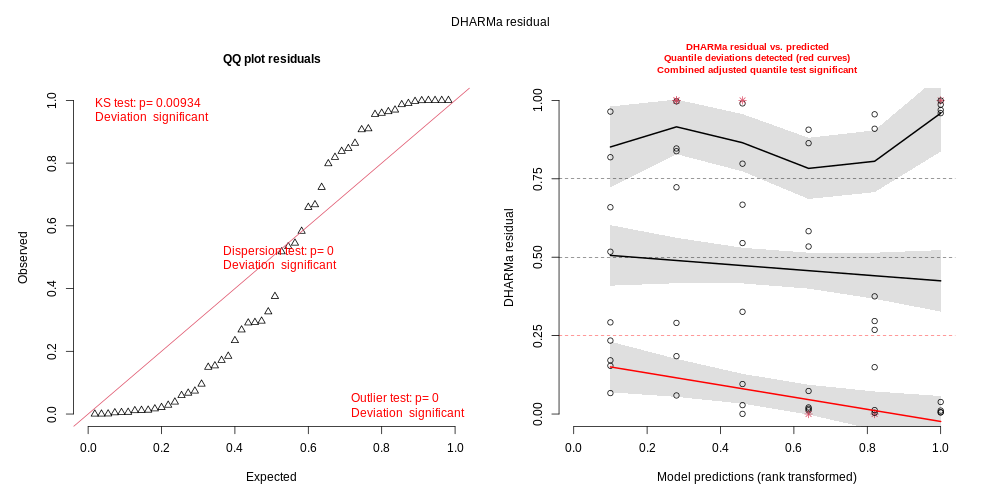


=== Step 3: Negative binomial refit ===
AIC:       408.76  (vs Poisson 493.06; Δ=84.3)
theta_:    9.944 (+/- 2.561)
  (lower theta = more overdispersion; theta -> inf is Poisson)

=== Step 4: DHARMa on NB fit ===
Uniformity p-value: 0.8925  (should be > 0.05 if NB resolved misspecification)
Dispersion p-value: 0.5780  (should be > 0.05)
Outlier p-value:    1.0000

--- DHARMa plot for the NB fit (after) ---
(QQ residuals should now lie close to the diagonal; no significance markers expected)


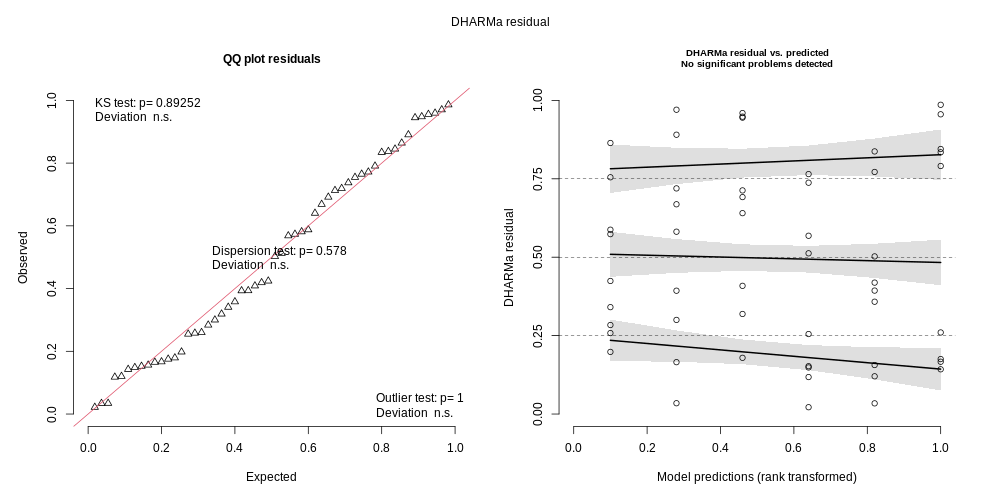


=== Before vs after summary ===
Test                       Poisson p-value       NB p-value
------------------------------------------------------------
Uniformity                          0.0093           0.8925
Dispersion                          0.0000           0.5780
Outliers                            0.0000           1.0000

(Higher p-values = better. NB should resolve at least the dispersion test; outlier and uniformity may also improve.)


In [ ]:
# Load warpbreaks from R's built-in datasets
ro.r("data(warpbreaks)")
warpbreaks = r_to_dataframe("warpbreaks")

# Convert factor columns to string for cleaner pandas handling
warpbreaks["wool"] = warpbreaks["wool"].astype(str)
warpbreaks["tension"] = warpbreaks["tension"].astype(str)

print(f"warpbreaks: {warpbreaks.shape}")
print(warpbreaks.head())
print(f"\nbreaks: mean = {warpbreaks['breaks'].mean():.2f}, "
      f"var = {warpbreaks['breaks'].var():.2f}")
print("(Variance >> mean is a hint of overdispersion before any fit)")

from IPython.display import Image, display

# --- Step 1: Fit Poisson ---
# The y column ("breaks") and predictors ("wool", "tension") get
# wrapped into the BaseRGLM auto-formula construction. We pass them
# as X/y for sklearn API consistency.
X_wb = warpbreaks[["wool", "tension"]]
y_wb = warpbreaks["breaks"].values

# Note: R's glm() handles factor predictors natively. Our wrapper
# pushes the DataFrame to R as-is (string columns become R factors),
# so this works without any one-hot encoding.
m_poi = RPoissonGLM().fit(X_wb, y_wb)

print(f"\n=== Step 1: Poisson fit ===")
print(f"AIC:       {m_poi.aic_:.2f}")
print(f"Deviance:  {m_poi.deviance_:.2f}")
print(f"df.resid:  {m_poi.df_resid_}")

# --- Step 2a: Quick dispersion check ---
disp = pearson_dispersion(m_poi)
print(f"\n=== Step 2a: Pearson dispersion ===")
print(f"Dispersion:    {disp['dispersion']:.3f}")
print(f"  (>1 suggests overdispersion; >1.5 strongly suggests "
      f"trying NB or quasi-Poisson)")
print(f"Pearson chi^2: {disp['pearson_chi2']:.2f}")
print(f"df.residual:   {disp['df_residual']}")

# --- Step 2b: DHARMa confirmation ---
# Use distinct plot paths so the two plots don't overwrite each other.
print(f"\n=== Step 2b: DHARMa diagnostics on Poisson fit ===")
dh_poi = dharma_diagnostics(
    m_poi, n_sim=1000, seed=42, plot=True,
    plot_path="/tmp/dharma_poisson.png",
)
print(f"Uniformity p-value: {dh_poi['uniformity_pvalue']:.4f}  "
      f"(low = residuals not uniform = misspecification)")
print(f"Dispersion p-value: {dh_poi['dispersion_pvalue']:.4f}  "
      f"(low = significant dispersion problem)")
print(f"Outlier p-value:    {dh_poi['outlier_pvalue']:.4f}")

# Show the "before" plot -- problem detected
print(f"\n--- DHARMa plot for the Poisson fit (before) ---")
print("(Left: QQ-plot of scaled residuals; right: residuals vs predicted)")
display(Image(dh_poi["plot_path"]))

# --- Step 3: Refit with NB ---
m_nb = RNegBinGLM().fit(X_wb, y_wb)

print(f"\n=== Step 3: Negative binomial refit ===")
print(f"AIC:       {m_nb.aic_:.2f}  "
      f"(vs Poisson {m_poi.aic_:.2f}; Δ={m_poi.aic_ - m_nb.aic_:.1f})")
print(f"theta_:    {m_nb.theta_:.3f} (+/- {m_nb.se_theta_:.3f})")
print(f"  (lower theta = more overdispersion; theta -> inf is Poisson)")

# --- Step 4: Confirm NB resolved the problem ---
print(f"\n=== Step 4: DHARMa on NB fit ===")
dh_nb = dharma_diagnostics(
    m_nb, n_sim=1000, seed=42, plot=True,
    plot_path="/tmp/dharma_negbin.png",
)
print(f"Uniformity p-value: {dh_nb['uniformity_pvalue']:.4f}  "
      f"(should be > 0.05 if NB resolved misspecification)")
print(f"Dispersion p-value: {dh_nb['dispersion_pvalue']:.4f}  "
      f"(should be > 0.05)")
print(f"Outlier p-value:    {dh_nb['outlier_pvalue']:.4f}")

# Show the "after" plot -- problem resolved
print(f"\n--- DHARMa plot for the NB fit (after) ---")
print("(QQ residuals should now lie close to the diagonal; "
      "no significance markers expected)")
display(Image(dh_nb["plot_path"]))

# Summary contrast
print(f"\n=== Before vs after summary ===")
print(f"{'Test':<22s}  {'Poisson p-value':>18s}  {'NB p-value':>15s}")
print("-" * 60)
for test_key, label in [
    ("uniformity_pvalue", "Uniformity"),
    ("dispersion_pvalue", "Dispersion"),
    ("outlier_pvalue",    "Outliers"),
]:
    print(f"{label:<22s}  {dh_poi[test_key]:>18.4f}  "
          f"{dh_nb[test_key]:>15.4f}")
print("\n(Higher p-values = better. NB should resolve at least the "
      "dispersion test; outlier and uniformity may also improve.)")

In [ ]:
from sklearn.datasets import fetch_california_housing

cali = fetch_california_housing(as_frame=True)

# Subsample for speed
np.random.seed(0)
sub_idx = np.random.choice(len(cali.data), size=2000, replace=False)
X_cali_sub = cali.data.iloc[sub_idx]
y_cali_sub = cali.target.iloc[sub_idx].values

print(f"California Housing (subsample): X={X_cali_sub.shape}\n")

m_gauss = RGaussianGLM().fit(X_cali_sub, y_cali_sub)

print("=== RGaussianGLM coefficient table ===")
print(m_gauss.coef_table_.round(4))
print(f"\nAIC:         {m_gauss.aic_:.2f}")
print(f"Deviance:    {m_gauss.deviance_:.2f}")
print(f"In-sample R^2: {m_gauss.score(X_cali_sub, y_cali_sub):.4f}")

# CV
from sklearn.model_selection import cross_val_score
cv_r2 = cross_val_score(
    RGaussianGLM(),
    X_cali_sub,
    y_cali_sub,
    cv=5,
    scoring="r2"
)
print(f"5-fold CV R^2: {cv_r2.mean():.4f} (+/- {cv_r2.std():.4f})")

California Housing (subsample): X=(2000, 8)

=== RGaussianGLM coefficient table ===
             Estimate  Std. Error  t value  Pr(>|t|)
(Intercept)  -37.9607      2.1265 -17.8513    0.0000
MedInc         0.4546      0.0133  34.2071    0.0000
HouseAge       0.0101      0.0014   7.0997    0.0000
AveRooms      -0.1409      0.0191  -7.3931    0.0000
AveBedrms      0.8436      0.0919   9.1763    0.0000
Population     0.0000      0.0000   1.1108    0.2668
AveOccup      -0.0033      0.0006  -5.5170    0.0000
Latitude      -0.4320      0.0232 -18.6253    0.0000
Longitude     -0.4449      0.0243 -18.3396    0.0000

AIC:         4439.02
Deviance:    1066.92
In-sample R^2: 0.6152
5-fold CV R^2: -24.4965 (+/- 50.2174)


# Section 3: Machine Learning Models

In [ ]:
"""
BaseRClassifier: shared plumbing for non-formula R-backed classifiers
(and the regressors, via _is_classifier = False).

Subclasses must:
  1. Inherit from this AND a sklearn task mixin (ClassifierMixin or
     RegressorMixin), with the mixin first (sklearn convention).
  2. Set _required_r_package to the name of the R package to verify
     at fit time (e.g. "e1071").
  3. Set _is_classifier = True (default) or False for regressors.
  4. Implement _fit_r_model(): write R code that fits the model
     reading from R_TRAIN_DF and assigning to R_MODEL.
  5. For classifiers, implement _predict_r_classes() and
     _predict_r_proba(). For regressors, implement _predict_r_response()
     by overriding _predict_r_classes (the base class's predict() routes
     through it for regressors).
  6. Optionally override _extract_subclass_attributes() to pull
     subclass-specific fitted attributes.

Some classifiers (RGBMClassifier) need a non-factor y encoding -- they
override fit() directly while still using the rest of the base class
infrastructure for input validation and escape hatches.
"""

from rpy2.robjects.packages import isinstalled


class BaseRClassifier(BaseEstimator, ABC):
    """Shared base for non-formula R-backed classifiers and regressors."""

    _required_r_package: str = ""
    _is_classifier: bool = True

    @abstractmethod
    def _fit_r_model(self) -> None:
        """
        Fit the R model. Read training data from R_TRAIN_DF (a
        data.frame); the response column is R_Y_COLNAME (rsk_y).
        For classifiers it's already a factor with levels in
        self.classes_ order. Assign the fitted model to R_MODEL.
        """

    @abstractmethod
    def _predict_r_classes(self):
        """
        For classifiers: return rpy2 list with members
            codes  -- integer factor codes (1-indexed) for each row
            levels -- character vector of factor level names

        For regressors: return an R numeric vector.
        """

    def _predict_r_proba(self):
        """
        Classifier-only: return rpy2 list with members
            values   -- numeric (n_rows, n_classes) probability matrix
            colnames -- class labels matching matrix columns
        """
        raise NotImplementedError(
            "_predict_r_proba must be overridden by classifiers"
        )

    def _extract_subclass_attributes(self) -> None:
        """Optional hook: pull subclass-specific fitted attributes."""
        pass

    # ------------------------------------------------------------------ #
    # Public sklearn surface
    # ------------------------------------------------------------------ #
    def fit(self, X, y):
        self._check_r_package_available()
        X_df, y_arr = self._validate_fit_inputs(X, y)
        self.feature_names_in_ = list(X_df.columns)
        self.n_features_in_ = len(self.feature_names_in_)

        df = X_df.copy()

        if self._is_classifier:
            self.classes_ = np.unique(y_arr)
            self.n_classes_ = len(self.classes_)
            if self.n_classes_ < 2:
                raise ValueError(
                    f"y must have at least 2 distinct classes; got "
                    f"{self.n_classes_}: {list(self.classes_)!r}"
                )
            # String round-trip for safe factor encoding
            df[R_Y_COLNAME] = pd.Series(y_arr, index=df.index).astype(str)
            self._push_dataframe(df, R_TRAIN_DF)

            # Set factor levels in classes_ order so predict_proba columns
            # are pre-aligned to sklearn convention.
            levels_str = ", ".join(
                f'"{c}"' for c in self.classes_.astype(str)
            )
            ro.r(f"""
                {R_TRAIN_DF}${R_Y_COLNAME} <- factor(
                    {R_TRAIN_DF}${R_Y_COLNAME},
                    levels = c({levels_str})
                )
            """)
        else:
            df[R_Y_COLNAME] = y_arr.astype(float)
            self._push_dataframe(df, R_TRAIN_DF)

        self._fit_r_model()
        self.r_object_ = ro.globalenv[R_MODEL]
        self._extract_subclass_attributes()
        return self

    def predict(self, X) -> np.ndarray:
        """Class labels (classifiers) or response (regressors)."""
        check_is_fitted(self, "r_object_")
        X_df = self._validate_predict_input(X)
        ro.globalenv[R_MODEL] = self.r_object_
        self._push_dataframe(X_df, R_PREDICT_DF)

        if not self._is_classifier:
            preds_r = self._predict_r_classes()
            return r_to_numpy(preds_r).ravel()

        result = self._predict_r_classes()
        codes = r_to_numpy(result.rx2("codes"))
        levels = list(result.rx2("levels"))
        levels_to_class = {str(c): c for c in self.classes_}
        return np.array([levels_to_class[levels[c - 1]] for c in codes])

    def predict_proba(self, X) -> np.ndarray:
        """(n, n_classes) probability matrix, columns ordered by classes_."""
        if not self._is_classifier:
            raise AttributeError(
                "predict_proba is not available on regressors"
            )
        check_is_fitted(self, "r_object_")
        X_df = self._validate_predict_input(X)
        ro.globalenv[R_MODEL] = self.r_object_
        self._push_dataframe(X_df, R_PREDICT_DF)

        result = self._predict_r_proba()
        proba_matrix = r_to_numpy(result.rx2("values"))
        col_names = list(result.rx2("colnames"))

        # Defensive reordering -- some R packages reorder columns
        expected_cols = [str(c) for c in self.classes_]
        if col_names != expected_cols:
            order = [col_names.index(c) for c in expected_cols]
            proba_matrix = proba_matrix[:, order]
        return proba_matrix

    # ------------------------------------------------------------------ #
    # Escape hatches (same shape as BaseRGLM)
    # ------------------------------------------------------------------ #
    def summary(self) -> str:
        check_is_fitted(self, "r_object_")
        ro.globalenv[R_MODEL] = self.r_object_
        return str(ro.r(
            f'paste(capture.output(print({R_MODEL})), collapse = "\\n")'
        )[0])

    def run_r(self, code: str):
        check_is_fitted(self, "r_object_")
        ro.globalenv[R_MODEL] = self.r_object_
        return ro.r(code)

    # ------------------------------------------------------------------ #
    # Internal helpers
    # ------------------------------------------------------------------ #
    def _check_r_package_available(self) -> None:
        if not self._required_r_package:
            return
        if not isinstalled(self._required_r_package):
            raise RuntimeError(
                f"{type(self).__name__} requires R package "
                f"{self._required_r_package!r}, which is not installed.\n"
                f"Install via: env.install(["
                f"{self._required_r_package!r}])"
            )

    def _validate_fit_inputs(self, X, y):
        if isinstance(X, pd.DataFrame):
            X_df = X.copy()
        else:
            X_arr = np.asarray(X)
            if X_arr.ndim != 2:
                raise ValueError(f"X must be 2D; got {X_arr.shape}")
            X_df = pd.DataFrame(
                X_arr,
                columns=[f"X{i}" for i in range(X_arr.shape[1])],
            )
        cols = list(X_df.columns)
        if len(set(cols)) != len(cols):
            raise ValueError(f"X has duplicate column names: {cols}")
        if R_Y_COLNAME in cols:
            raise ValueError(
                f"X has a column named {R_Y_COLNAME!r}, which collides "
                f"with the internal response variable name."
            )
        y_arr = np.asarray(y).ravel()
        if len(y_arr) != len(X_df):
            raise ValueError(
                f"X and y length mismatch: X={len(X_df)}, y={len(y_arr)}"
            )
        return X_df, y_arr

    def _validate_predict_input(self, X) -> pd.DataFrame:
        if isinstance(X, pd.DataFrame):
            X_df = X.copy()
        else:
            X_arr = np.asarray(X)
            if X_arr.ndim != 2:
                raise ValueError(f"X must be 2D; got {X_arr.shape}")
            if X_arr.shape[1] != self.n_features_in_:
                raise ValueError(
                    f"X has {X_arr.shape[1]} columns; expected "
                    f"{self.n_features_in_}"
                )
            X_df = pd.DataFrame(X_arr, columns=self.feature_names_in_)
        missing = [c for c in self.feature_names_in_
                   if c not in X_df.columns]
        if missing:
            raise ValueError(f"X missing columns: {missing}")
        return X_df[self.feature_names_in_]

    @staticmethod
    def _push_dataframe(df: pd.DataFrame, r_name: str) -> None:
        with localconverter(default_converter + pandas2ri.converter):
            r_df = ro.conversion.py2rpy(df)
        ro.globalenv[r_name] = r_df

In [ ]:
"""
Random forest classifier via R's randomForest::randomForest().

Beyond sklearn equivalents:
  * feature_importances_ available without importance=True
  * oob_score_ -- out-of-bag accuracy from the OOB confusion matrix
  * confusion_matrix_ -- the full OOB confusion matrix

Inheritance note: ClassifierMixin comes BEFORE BaseRClassifier in the
MRO. This is sklearn's convention and is required so that sklearn's
internal _estimator_type lookup correctly identifies these classes
as classifiers (otherwise scoring methods like roc_auc fail because
sklearn falls back to treating them as regressors).
"""

from typing import Union


class RRandomForestClassifier(ClassifierMixin, BaseRClassifier):
    """
    Random forest classifier backed by R's randomForest package.

    Parameters
    ----------
    n_estimators : int, default 500
        R's ntree.
    max_features : int or "sqrt" or None, default "sqrt"
        R's mtry. For classification, R's default is floor(sqrt(p)).
    min_samples_leaf : int, default 1
        R's nodesize.
    max_nodes : int, optional
        R's maxnodes.
    bootstrap : bool, default True
        R's replace.
    sample_size : int, optional
        R's sampsize.
    importance : bool, default False
        Compute permutation-based variable importance.
        If False (default), uses Gini importance.
    random_state : int, optional
        Calls set.seed(random_state) in R before fitting.

    Fitted attributes
    -----------------
    feature_importances_ : ndarray of shape (n_features_in_,)
    oob_score_ : float
        OOB accuracy from the confusion matrix.
    confusion_matrix_ : pandas.DataFrame
        OOB confusion matrix (last column is "class.error").
    """

    _required_r_package = "randomForest"

    def __init__(
        self,
        n_estimators: int = 500,
        max_features: Union[int, str, None] = "sqrt",
        min_samples_leaf: int = 1,
        max_nodes: Optional[int] = None,
        bootstrap: bool = True,
        sample_size: Optional[int] = None,
        importance: bool = False,
        random_state: Optional[int] = None,
    ):
        self.n_estimators = n_estimators
        self.max_features = max_features
        self.min_samples_leaf = min_samples_leaf
        self.max_nodes = max_nodes
        self.bootstrap = bootstrap
        self.sample_size = sample_size
        self.importance = importance
        self.random_state = random_state

    def _build_rf_args(self) -> list:
        """Shared arg builder used by both classifier and regressor."""
        args = [
            f"y = {R_TRAIN_DF}${R_Y_COLNAME}",
            f"x = {R_TRAIN_DF}[, names({R_TRAIN_DF}) != "
            f'"{R_Y_COLNAME}", drop = FALSE]',
            f"ntree = {self.n_estimators}",
            f"nodesize = {self.min_samples_leaf}",
            f"replace = {'TRUE' if self.bootstrap else 'FALSE'}",
            f"importance = {'TRUE' if self.importance else 'FALSE'}",
        ]
        if self.max_features == "sqrt" or self.max_features is None:
            pass
        elif isinstance(self.max_features, (int, np.integer)):
            args.append(f"mtry = {int(self.max_features)}")
        else:
            raise ValueError(
                f"max_features must be int, 'sqrt', or None; "
                f"got {self.max_features!r}"
            )
        if self.max_nodes is not None:
            args.append(f"maxnodes = {self.max_nodes}")
        if self.sample_size is not None:
            args.append(f"sampsize = {self.sample_size}")
        return args

    def _fit_r_model(self) -> None:
        args = self._build_rf_args()
        seed_call = (
            f"set.seed({self.random_state})\n"
            if self.random_state is not None
            else ""
        )
        ro.r(f"""
            {seed_call}
            {R_MODEL} <- randomForest::randomForest(
                {', '.join(args)}
            )
        """)

    def _predict_r_classes(self):
        return ro.r(f"""
            .rsk_pred <- predict({R_MODEL}, newdata = {R_PREDICT_DF})
            list(
                codes = as.integer(.rsk_pred),
                levels = levels(.rsk_pred)
            )
        """)

    def _predict_r_proba(self):
        return ro.r(f"""
            .rsk_proba <- predict({R_MODEL}, newdata = {R_PREDICT_DF},
                                  type = "prob")
            list(
                values = .rsk_proba,
                colnames = colnames(.rsk_proba)
            )
        """)

    def _extract_subclass_attributes(self) -> None:
        # OOB confusion matrix
        conf_arr = r_to_numpy(ro.r(f"{R_MODEL}$confusion"))
        rownames = list(ro.r(f"rownames({R_MODEL}$confusion)"))
        colnames = list(ro.r(f"colnames({R_MODEL}$confusion)"))
        self.confusion_matrix_ = pd.DataFrame(
            conf_arr, index=rownames, columns=colnames,
        )
        counts = self.confusion_matrix_.iloc[:, :-1].values
        n_correct = float(np.diag(counts).sum())
        n_total = float(counts.sum())
        self.oob_score_ = (
            n_correct / n_total if n_total > 0 else float("nan")
        )

        # Feature importances
        if self.importance:
            imp_matrix = r_to_numpy(ro.r(f"{R_MODEL}$importance"))
            imp_colnames = list(ro.r(f"colnames({R_MODEL}$importance)"))
            imp_rownames = list(ro.r(f"rownames({R_MODEL}$importance)"))
            mda_idx = imp_colnames.index("MeanDecreaseAccuracy")
            importances = imp_matrix[:, mda_idx]
        else:
            imp_matrix = r_to_numpy(
                ro.r(f"{R_MODEL}$importance")
            ).ravel()
            imp_rownames = list(ro.r(f"rownames({R_MODEL}$importance)"))
            importances = imp_matrix

        if list(imp_rownames) == list(self.feature_names_in_):
            self.feature_importances_ = importances
        else:
            order = [imp_rownames.index(name)
                     for name in self.feature_names_in_]
            self.feature_importances_ = importances[order]

In [ ]:
"""
SVM classifier via R's e1071::svm.

e1071's predict idiom for probabilities is unusual: you call
predict(model, ..., probability=TRUE) and then read
attr(result, "probabilities") for the matrix.
"""


class RSVMClassifier(ClassifierMixin, BaseRClassifier):
    """
    Support vector machine classifier backed by R's e1071::svm.

    Parameters
    ----------
    C : float, default 1.0
        Cost of constraint violation (R's `cost`).
    kernel : str, default "radial"
        One of "linear", "polynomial", "radial", "sigmoid".
    degree : int, default 3
        Polynomial kernel degree (ignored for other kernels).
    gamma : float, optional
        Kernel parameter. Default: 1 / n_features.
    coef0 : float, default 0.0
        Used by polynomial and sigmoid kernels.
    shrinking : bool, default True
    random_state : int, optional

    Fitted attributes
    -----------------
    n_support_vectors_ : int
        Total number of support vectors.
    """

    _required_r_package = "e1071"

    def __init__(
        self,
        C: float = 1.0,
        kernel: str = "radial",
        degree: int = 3,
        gamma: Optional[float] = None,
        coef0: float = 0.0,
        shrinking: bool = True,
        random_state: Optional[int] = None,
    ):
        self.C = C
        self.kernel = kernel
        self.degree = degree
        self.gamma = gamma
        self.coef0 = coef0
        self.shrinking = shrinking
        self.random_state = random_state

    def _fit_r_model(self) -> None:
        if self.kernel not in ("linear", "polynomial", "radial", "sigmoid"):
            raise ValueError(
                f"kernel must be one of 'linear', 'polynomial', "
                f"'radial', 'sigmoid'; got {self.kernel!r}"
            )
        args = [
            f"y = {R_TRAIN_DF}${R_Y_COLNAME}",
            f"x = {R_TRAIN_DF}[, names({R_TRAIN_DF}) != "
            f'"{R_Y_COLNAME}", drop = FALSE]',
            f'kernel = "{self.kernel}"',
            f"cost = {self.C}",
            f"degree = {self.degree}",
            f"coef0 = {self.coef0}",
            f"shrinking = {'TRUE' if self.shrinking else 'FALSE'}",
            "probability = TRUE",  # always enable so predict_proba works
        ]
        if self.gamma is not None:
            args.append(f"gamma = {self.gamma}")

        seed_call = (
            f"set.seed({self.random_state})\n"
            if self.random_state is not None
            else ""
        )
        ro.r(f"""
            {seed_call}
            {R_MODEL} <- e1071::svm({', '.join(args)})
        """)

    def _predict_r_classes(self):
        return ro.r(f"""
            .rsk_pred <- predict({R_MODEL}, newdata = {R_PREDICT_DF})
            list(
                codes = as.integer(.rsk_pred),
                levels = levels(.rsk_pred)
            )
        """)

    def _predict_r_proba(self):
        # e1071 returns predicted classes as the main result and the
        # probability matrix as an attribute. Extract the attr.
        return ro.r(f"""
            .rsk_pred <- predict({R_MODEL}, newdata = {R_PREDICT_DF},
                                 probability = TRUE)
            .rsk_proba <- attr(.rsk_pred, "probabilities")
            list(
                values = .rsk_proba,
                colnames = colnames(.rsk_proba)
            )
        """)

    def _extract_subclass_attributes(self) -> None:
        self.n_support_vectors_ = int(
            ro.r(f"{R_MODEL}$tot.nSV")[0]
        )

In [ ]:
"""
Two more classifiers, both with quirky predict idioms:

  * naiveBayes uses type="raw" for probabilities (not "prob")
  * lda returns predictions as a list with $class and $posterior members
"""


class RNaiveBayesClassifier(ClassifierMixin, BaseRClassifier):
    """
    Naive Bayes classifier backed by R's e1071::naiveBayes.

    Parameters
    ----------
    laplace : float, default 0.0
        Laplace smoothing parameter.
    """

    _required_r_package = "e1071"

    def __init__(self, laplace: float = 0.0):
        self.laplace = laplace

    def _fit_r_model(self) -> None:
        ro.r(f"""
            {R_MODEL} <- e1071::naiveBayes(
                y = {R_TRAIN_DF}${R_Y_COLNAME},
                x = {R_TRAIN_DF}[, names({R_TRAIN_DF}) != "{R_Y_COLNAME}",
                                  drop = FALSE],
                laplace = {self.laplace}
            )
        """)

    def _predict_r_classes(self):
        return ro.r(f"""
            .rsk_pred <- predict({R_MODEL}, newdata = {R_PREDICT_DF},
                                 type = "class")
            list(
                codes = as.integer(.rsk_pred),
                levels = levels(.rsk_pred)
            )
        """)

    def _predict_r_proba(self):
        # naiveBayes uses type="raw" for probabilities
        return ro.r(f"""
            .rsk_proba <- predict({R_MODEL}, newdata = {R_PREDICT_DF},
                                  type = "raw")
            list(
                values = .rsk_proba,
                colnames = colnames(.rsk_proba)
            )
        """)


class RLDAClassifier(ClassifierMixin, BaseRClassifier):
    """
    Linear discriminant analysis backed by R's MASS::lda.

    MASS::lda's predict idiom: the result is a list with members $class
    (predicted classes) and $posterior (probabilities), not the standard
    predict-with-type-arg pattern.

    Parameters
    ----------
    prior : array-like, optional
        Class prior probabilities. Default: estimated from training data.

    Fitted attributes
    -----------------
    means_ : pandas.DataFrame
        Class means, indexed by class with columns matching feature_names_in_.
    """

    _required_r_package = "MASS"

    def __init__(self, prior: Optional[list] = None):
        self.prior = prior

    def _fit_r_model(self) -> None:
        prior_arg = ""
        if self.prior is not None:
            prior_vals = ", ".join(str(float(p)) for p in self.prior)
            prior_arg = f", prior = c({prior_vals})"

        ro.r(f"""
            {R_MODEL} <- MASS::lda(
                grouping = {R_TRAIN_DF}${R_Y_COLNAME},
                x = {R_TRAIN_DF}[, names({R_TRAIN_DF}) != "{R_Y_COLNAME}",
                                  drop = FALSE]
                {prior_arg}
            )
        """)

    def _predict_r_classes(self):
        return ro.r(f"""
            .rsk_pred_obj <- predict({R_MODEL}, newdata = {R_PREDICT_DF})
            .rsk_pred <- .rsk_pred_obj$class
            list(
                codes = as.integer(.rsk_pred),
                levels = levels(.rsk_pred)
            )
        """)

    def _predict_r_proba(self):
        return ro.r(f"""
            .rsk_pred_obj <- predict({R_MODEL}, newdata = {R_PREDICT_DF})
            .rsk_proba <- .rsk_pred_obj$posterior
            list(
                values = .rsk_proba,
                colnames = colnames(.rsk_proba)
            )
        """)

    def _extract_subclass_attributes(self) -> None:
        means_arr = r_to_numpy(ro.r(f"{R_MODEL}$means"))
        rownames = list(ro.r(f"rownames({R_MODEL}$means)"))
        colnames = list(ro.r(f"colnames({R_MODEL}$means)"))
        self.means_ = pd.DataFrame(
            means_arr, index=rownames, columns=colnames,
        )

In [ ]:
"""
Random forest regressor via R's randomForest::randomForest().

randomForest::randomForest() automatically switches between
classification and regression based on whether y is a factor or numeric.
We set _is_classifier = False so the base class's fit() keeps y numeric;
the package handles the rest.
"""


class RRandomForestRegressor(RegressorMixin, BaseRClassifier):
    """
    Random forest regressor backed by R's randomForest package.

    Parameters identical to RRandomForestClassifier (R's regression
    default for nodesize is 5 instead of 1, reflected here).

    Fitted attributes
    -----------------
    feature_importances_ : ndarray of shape (n_features_in_,)
        For regression, R reports "%IncMSE" (when importance=True) or
        "IncNodePurity" (when importance=False).
    oob_score_ : float
        Out-of-bag R^2 estimate (R's $rsq, last value).
    oob_mse_ : float
        Out-of-bag MSE (R's $mse, last value).
    """

    _required_r_package = "randomForest"
    _is_classifier = False

    def __init__(
        self,
        n_estimators: int = 500,
        max_features: Union[int, str, None] = "sqrt",
        min_samples_leaf: int = 5,  # R's regression default
        max_nodes: Optional[int] = None,
        bootstrap: bool = True,
        sample_size: Optional[int] = None,
        importance: bool = False,
        random_state: Optional[int] = None,
    ):
        self.n_estimators = n_estimators
        self.max_features = max_features
        self.min_samples_leaf = min_samples_leaf
        self.max_nodes = max_nodes
        self.bootstrap = bootstrap
        self.sample_size = sample_size
        self.importance = importance
        self.random_state = random_state

    def _fit_r_model(self) -> None:
        # Reuse the classifier's arg builder by direct invocation
        args = RRandomForestClassifier._build_rf_args(self)
        seed_call = (
            f"set.seed({self.random_state})\n"
            if self.random_state is not None
            else ""
        )
        ro.r(f"""
            {seed_call}
            {R_MODEL} <- randomForest::randomForest(
                {', '.join(args)}
            )
        """)

    def _predict_r_classes(self):
        # For regressors, return raw response vector (the base class's
        # predict() handles the _is_classifier=False path)
        return ro.r(
            f'predict({R_MODEL}, newdata = {R_PREDICT_DF})'
        )

    def _extract_subclass_attributes(self) -> None:
        # For regression, model$confusion doesn't exist. Get OOB MSE
        # and R^2 from $mse and $rsq (one per ntree; last value is final).
        mse_vec = r_to_numpy(ro.r(f"{R_MODEL}$mse"))
        rsq_vec = r_to_numpy(ro.r(f"{R_MODEL}$rsq"))
        self.oob_mse_ = float(mse_vec[-1])
        self.oob_score_ = float(rsq_vec[-1])

        if self.importance:
            imp_matrix = r_to_numpy(ro.r(f"{R_MODEL}$importance"))
            imp_colnames = list(ro.r(f"colnames({R_MODEL}$importance)"))
            imp_rownames = list(ro.r(f"rownames({R_MODEL}$importance)"))
            mse_idx = imp_colnames.index("%IncMSE")
            importances = imp_matrix[:, mse_idx]
        else:
            imp_matrix = r_to_numpy(
                ro.r(f"{R_MODEL}$importance")
            ).ravel()
            imp_rownames = list(ro.r(f"rownames({R_MODEL}$importance)"))
            importances = imp_matrix

        if list(imp_rownames) == list(self.feature_names_in_):
            self.feature_importances_ = importances
        else:
            order = [imp_rownames.index(name)
                     for name in self.feature_names_in_]
            self.feature_importances_ = importances[order]

In [ ]:
"""
Gradient boosting machine wrappers via R's gbm::gbm().

Two classes that share an attribute-extraction helper:
  * RGBMClassifier -- binary, distribution="bernoulli"
  * RGBMRegressor  -- continuous, distribution in {"gaussian",
                      "laplace", "tdist"}

Both wrap the same R fit function; the differences are y encoding
(0/1 numeric vs raw numeric), the distribution argument, and the
predict idiom (1D probability vs 1D response).

gbm() quirks the wrappers handle:
  * Uses formula syntax like glm() -- we auto-build from X columns
  * predict.gbm needs n.trees= at predict time; we always use all trees
  * Verbose output unless explicitly silenced
"""


def _extract_gbm_attributes(model_self) -> None:
    """
    Shared fitted-attribute extraction for both GBM classes.
    Called from each class's _extract_subclass_attributes().

    Sets on model_self:
      n_estimators_         -- int, actual tree count
      feature_importances_  -- ndarray, normalized to sum to 1
      train_error_          -- ndarray, training deviance trajectory
    """
    model_self.n_estimators_ = int(ro.r(f"{R_MODEL}$n.trees")[0])

    # Variable importance: gbm calls it "relative influence"
    with localconverter(default_converter + pandas2ri.converter):
        imp_df = ro.conversion.rpy2py(ro.r(
            f"summary({R_MODEL}, plotit = FALSE, order = FALSE)"
        ))
    # Reorder to match feature_names_in_ and rescale to sum to 1
    imp_dict = dict(zip(imp_df["var"].astype(str),
                        imp_df["rel.inf"].astype(float)))
    raw = np.array(
        [imp_dict[name] for name in model_self.feature_names_in_]
    )
    total = raw.sum()
    model_self.feature_importances_ = (
        raw / total if total > 0 else raw
    )

    # Training deviance trajectory
    model_self.train_error_ = r_to_numpy(ro.r(f"{R_MODEL}$train.error"))


class RGBMClassifier(ClassifierMixin, BaseRClassifier):
    """
    Binary GBM classifier backed by R's gbm package.

    Parameters
    ----------
    n_estimators : int, default 100
        Number of trees (R's `n.trees`).
    learning_rate : float, default 0.1
        Shrinkage applied to each tree's contribution (R's `shrinkage`).
        gbm's default is 0.001 (very conservative); we use 0.1 to match
        sklearn's `HistGradientBoostingClassifier` default.
    max_depth : int, default 3
        Maximum interaction depth (R's `interaction.depth`).
        1 = stumps (additive model), 3 = pairwise interactions, etc.
    min_samples_leaf : int, default 10
        Minimum observations per terminal node (R's `n.minobsinnode`).
    subsample : float, default 0.5
        Fraction of training data sampled per tree (R's `bag.fraction`).
        0.5 enables stochastic gradient boosting (Friedman 2002);
        1.0 disables.
    random_state : int, optional
        Calls set.seed(random_state) in R before fitting.

    Fitted attributes
    -----------------
    n_estimators_ : int
        Actual number of trees in the fitted model.
    feature_importances_ : ndarray of shape (n_features_in_,)
        Relative influence of each feature, normalized to sum to 1.
    train_error_ : ndarray of shape (n_estimators_,)
        Training deviance after each iteration. Useful for diagnosing
        overfitting -- if train_error_ keeps dropping but CV doesn't,
        you've fit too many trees.

    Notes
    -----
    Currently binary-only. Multinomial classification via
    distribution="multinomial" is officially deprecated in gbm; users
    with multiclass problems should use RRandomForestClassifier or
    RSVMClassifier.
    """

    _required_r_package = "gbm"

    def __init__(
        self,
        n_estimators: int = 100,
        learning_rate: float = 0.1,
        max_depth: int = 3,
        min_samples_leaf: int = 10,
        subsample: float = 0.5,
        random_state: Optional[int] = None,
    ):
        self.n_estimators = n_estimators
        self.learning_rate = learning_rate
        self.max_depth = max_depth
        self.min_samples_leaf = min_samples_leaf
        self.subsample = subsample
        self.random_state = random_state

    def fit(self, X, y):
        """
        Override BaseRClassifier.fit because gbm needs 0/1 numeric y,
        not a factor.
        """
        self._check_r_package_available()
        X_df, y_arr = self._validate_fit_inputs(X, y)

        unique = np.unique(y_arr)
        if len(unique) != 2:
            raise ValueError(
                f"RGBMClassifier requires binary y; got {len(unique)} "
                f"unique values: {unique}"
            )

        self.feature_names_in_ = list(X_df.columns)
        self.n_features_in_ = len(self.feature_names_in_)
        self.classes_ = unique
        self.n_classes_ = 2

        # Encode y as 0/1 numeric (gbm with distribution="bernoulli")
        y_binary = (y_arr == self.classes_[1]).astype(int)
        df = X_df.copy()
        df[R_Y_COLNAME] = y_binary
        self._push_dataframe(df, R_TRAIN_DF)

        quoted = [r_quote_name(c) for c in self.feature_names_in_]
        formula = f"{R_Y_COLNAME} ~ {' + '.join(quoted)}"
        self.formula_ = formula

        self._fit_r_model()
        self.r_object_ = ro.globalenv[R_MODEL]
        self._extract_subclass_attributes()
        return self

    def _fit_r_model(self) -> None:
        seed_call = (
            f"set.seed({self.random_state})\n"
            if self.random_state is not None
            else ""
        )
        ro.r(f"""
            {seed_call}
            {R_MODEL} <- gbm::gbm(
                formula = {self.formula_},
                data = {R_TRAIN_DF},
                distribution = "bernoulli",
                n.trees = {self.n_estimators},
                interaction.depth = {self.max_depth},
                shrinkage = {self.learning_rate},
                n.minobsinnode = {self.min_samples_leaf},
                bag.fraction = {self.subsample},
                verbose = FALSE
            )
        """)

    def _predict_r_classes(self):
        # We override predict() directly to handle gbm's 1D output
        # shape, so this abstract-method stub is unused. It must exist
        # for instantiation to be allowed by the abstract base class.
        raise NotImplementedError(
            "RGBMClassifier overrides predict() directly; this hook "
            "is unused."
        )

    def _predict_r_proba(self):
        # Same -- we override predict_proba() directly
        raise NotImplementedError(
            "RGBMClassifier overrides predict_proba() directly; this "
            "hook is unused."
        )

    def predict_proba(self, X) -> np.ndarray:
        check_is_fitted(self, "r_object_")
        X_df = self._validate_predict_input(X)
        ro.globalenv[R_MODEL] = self.r_object_
        self._push_dataframe(X_df, R_PREDICT_DF)

        # gbm's predict returns positive-class probability as 1D vector
        p1 = r_to_numpy(ro.r(f"""
            as.numeric(predict({R_MODEL},
                               newdata = {R_PREDICT_DF},
                               n.trees = {R_MODEL}$n.trees,
                               type = "response"))
        """))
        p0 = 1.0 - p1
        return np.column_stack([p0, p1])

    def predict(self, X) -> np.ndarray:
        proba = self.predict_proba(X)
        class_idx = (proba[:, 1] > 0.5).astype(int)
        return self.classes_[class_idx]

    def _extract_subclass_attributes(self) -> None:
        _extract_gbm_attributes(self)


class RGBMRegressor(RegressorMixin, BaseRClassifier):
    """
    GBM regressor backed by R's gbm package.

    Uses the BaseRClassifier standard fit path with _is_classifier =
    False -- no fit() override needed since gbm regressors take numeric
    y the same way our other regressors do. The only quirk is the
    formula-based call (we build the formula in _fit_r_model).

    Parameters
    ----------
    n_estimators : int, default 100
    learning_rate : float, default 0.1
    max_depth : int, default 3
    min_samples_leaf : int, default 10
    subsample : float, default 0.5
        Same semantics as RGBMClassifier.
    distribution : str, default "gaussian"
        Loss function. One of:
          * "gaussian" -- least squares (the standard choice)
          * "laplace"  -- least absolute deviation (robust to outliers)
          * "tdist"    -- t-distribution loss (also robust)
    random_state : int, optional

    Fitted attributes
    -----------------
    n_estimators_ : int
    feature_importances_ : ndarray of shape (n_features_in_,)
    train_error_ : ndarray of shape (n_estimators_,)
        For regressors: training MSE (gaussian) or other loss-specific
        deviance trajectory.
    """

    _required_r_package = "gbm"
    _is_classifier = False

    _SUPPORTED_DISTRIBUTIONS = ("gaussian", "laplace", "tdist")

    def __init__(
        self,
        n_estimators: int = 100,
        learning_rate: float = 0.1,
        max_depth: int = 3,
        min_samples_leaf: int = 10,
        subsample: float = 0.5,
        distribution: str = "gaussian",
        random_state: Optional[int] = None,
    ):
        self.n_estimators = n_estimators
        self.learning_rate = learning_rate
        self.max_depth = max_depth
        self.min_samples_leaf = min_samples_leaf
        self.subsample = subsample
        self.distribution = distribution
        self.random_state = random_state

    def _fit_r_model(self) -> None:
        if self.distribution not in self._SUPPORTED_DISTRIBUTIONS:
            raise ValueError(
                f"distribution must be one of "
                f"{self._SUPPORTED_DISTRIBUTIONS}; "
                f"got {self.distribution!r}"
            )
        # Build formula here (the base class fit() doesn't, since
        # most non-formula classes don't need one)
        quoted = [r_quote_name(c) for c in self.feature_names_in_]
        formula = f"{R_Y_COLNAME} ~ {' + '.join(quoted)}"
        self.formula_ = formula

        seed_call = (
            f"set.seed({self.random_state})\n"
            if self.random_state is not None
            else ""
        )
        ro.r(f"""
            {seed_call}
            {R_MODEL} <- gbm::gbm(
                formula = {self.formula_},
                data = {R_TRAIN_DF},
                distribution = "{self.distribution}",
                n.trees = {self.n_estimators},
                interaction.depth = {self.max_depth},
                shrinkage = {self.learning_rate},
                n.minobsinnode = {self.min_samples_leaf},
                bag.fraction = {self.subsample},
                verbose = FALSE
            )
        """)

    def _predict_r_classes(self):
        # For regressors, return raw response vector (the base class's
        # predict() handles the _is_classifier=False path).
        # gbm needs n.trees= at predict time; use all of them.
        return ro.r(f"""
            as.numeric(predict({R_MODEL},
                               newdata = {R_PREDICT_DF},
                               n.trees = {R_MODEL}$n.trees,
                               type = "response"))
        """)

    def _extract_subclass_attributes(self) -> None:
        _extract_gbm_attributes(self)

In [ ]:
ML_CLASSIFIERS = [
    RRandomForestClassifier,
    RSVMClassifier,
    RNaiveBayesClassifier,
    RLDAClassifier,
    RGBMClassifier,
]

ML_REGRESSORS = [
    RRandomForestRegressor,
    RGBMRegressor,
]

# Sanity check: every class is correctly tagged via _is_classifier
assert all(c._is_classifier for c in ML_CLASSIFIERS), \
    "ML_CLASSIFIERS contains a class with _is_classifier=False"
assert all(not c._is_classifier for c in ML_REGRESSORS), \
    "ML_REGRESSORS contains a class with _is_classifier=True"

print(f"Defined {len(ML_CLASSIFIERS)} classifiers:")
for cls in ML_CLASSIFIERS:
    print(f"  {cls.__name__}")
print(f"\nDefined {len(ML_REGRESSORS)} regressors:")
for cls in ML_REGRESSORS:
    print(f"  {cls.__name__}")

Defined 5 classifiers:
  RRandomForestClassifier
  RSVMClassifier
  RNaiveBayesClassifier
  RLDAClassifier
  RGBMClassifier

Defined 2 regressors:
  RRandomForestRegressor
  RGBMRegressor


In [ ]:
from sklearn.datasets import load_iris

iris = load_iris(as_frame=True)
X_iris = iris.data
y_iris = iris.target

print(f"iris dataset: {X_iris.shape}, "
      f"{len(np.unique(y_iris))} classes\n")

# --- Random Forest ---
rf = RRandomForestClassifier(
    n_estimators=500, random_state=42, importance=True,
).fit(X_iris, y_iris)

print("=== RRandomForestClassifier ===")
print(f"OOB accuracy:        {rf.oob_score_:.4f}  "
      f"(no separate test set needed)\n")

print("Feature importances (mean decrease in accuracy):")
for name, imp in sorted(
    zip(rf.feature_names_in_, rf.feature_importances_),
    key=lambda x: -x[1],
):
    print(f"  {name:25s}  {imp:.4f}")

print("\nOOB confusion matrix:")
print(rf.confusion_matrix_.round(4))

iris dataset: (150, 4), 3 classes

=== RRandomForestClassifier ===
OOB accuracy:        0.9600  (no separate test set needed)

Feature importances (mean decrease in accuracy):
  petal length (cm)          0.3127
  petal width (cm)           0.2980
  sepal length (cm)          0.0308
  sepal width (cm)           0.0056

OOB confusion matrix:
      0     1     2  class.error
0  50.0   0.0   0.0         0.00
1   0.0  47.0   3.0         0.06
2   0.0   3.0  47.0         0.06


In [ ]:
# --- LDA ---
lda = RLDAClassifier().fit(X_iris, y_iris)

print("=== RLDAClassifier ===\n")
print("Class means (one of LDA's most useful diagnostic outputs):")
print(lda.means_.round(3))

# In-sample predictions
lda_preds = lda.predict(X_iris)
lda_proba = lda.predict_proba(X_iris)
print(f"\nIn-sample accuracy:  "
      f"{(lda_preds == y_iris.values).mean():.4f}")
print(f"predict_proba shape: {lda_proba.shape}  "
      f"(rows sum to 1: "
      f"{np.allclose(lda_proba.sum(axis=1), 1.0)})")

=== RLDAClassifier ===

Class means (one of LDA's most useful diagnostic outputs):
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0              5.006             3.428              1.462             0.246
1              5.936             2.770              4.260             1.326
2              6.588             2.974              5.552             2.026

In-sample accuracy:  0.9800
predict_proba shape: (150, 3)  (rows sum to 1: True)


In [ ]:
from sklearn.ensemble import RandomForestClassifier as SKLearnRF
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import cross_val_score

# Compare R-backed vs sklearn equivalents under the same CV protocol.
# The R-backed wrappers should give very similar accuracy.
print("5-fold CV accuracy comparison:\n")
for name, model in [
    ("R Random Forest              ", RRandomForestClassifier(
        n_estimators=500, random_state=42)),
    ("sklearn Random Forest        ", SKLearnRF(
        n_estimators=500, random_state=42)),
    ("R LDA                        ", RLDAClassifier()),
    ("sklearn LDA                  ", LinearDiscriminantAnalysis()),
]:
    scores = cross_val_score(model, X_iris, y_iris, cv=5)
    print(f"  {name}:  {scores.mean():.4f} (+/- {scores.std():.4f})")

5-fold CV accuracy comparison:

  R Random Forest              :  0.9600 (+/- 0.0249)
  sklearn Random Forest        :  0.9667 (+/- 0.0211)
  R LDA                        :  0.9800 (+/- 0.0267)
  sklearn LDA                  :  0.9800 (+/- 0.0267)


In [ ]:
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

wine = load_wine(as_frame=True)
X_wine = wine.data
y_wine = wine.target

print(f"wine dataset: {X_wine.shape}, "
      f"{len(np.unique(y_wine))} classes\n")

# --- SVM with RBF kernel ---
# SVMs are scale-sensitive, so we use sklearn's Pipeline to standardize
# features first. This also demonstrates that our R-backed classes are
# Pipeline-compatible.
svm = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", RSVMClassifier(kernel="radial", C=1.0, random_state=42)),
]).fit(X_wine, y_wine)

# After fit, attributes live on the named step
fitted_svm = svm.named_steps["svm"]
print(f"=== RSVMClassifier (RBF kernel, in Pipeline) ===")
print(f"Number of support vectors: {fitted_svm.n_support_vectors_}  "
      f"(out of {len(X_wine)} training samples)")
print(f"In-sample accuracy:        "
      f"{(svm.predict(X_wine) == y_wine.values).mean():.4f}")

# CV via the pipeline
cv_svm = cross_val_score(
    Pipeline([
        ("scaler", StandardScaler()),
        ("svm", RSVMClassifier(random_state=42)),
    ]),
    X_wine, y_wine, cv=5,
)
print(f"5-fold CV accuracy:        "
      f"{cv_svm.mean():.4f} (+/- {cv_svm.std():.4f})\n")

# --- Naive Bayes ---
nb = RNaiveBayesClassifier(laplace=0.0).fit(X_wine, y_wine)
nb_proba = nb.predict_proba(X_wine)
print(f"=== RNaiveBayesClassifier ===")
print(f"In-sample accuracy:        "
      f"{(nb.predict(X_wine) == y_wine.values).mean():.4f}")
print(f"predict_proba shape:       {nb_proba.shape}  "
      f"(rows sum to 1: "
      f"{np.allclose(nb_proba.sum(axis=1), 1.0)})")

cv_nb = cross_val_score(
    RNaiveBayesClassifier(), X_wine, y_wine, cv=5,
)
print(f"5-fold CV accuracy:        "
      f"{cv_nb.mean():.4f} (+/- {cv_nb.std():.4f})")

wine dataset: (178, 13), 3 classes

=== RSVMClassifier (RBF kernel, in Pipeline) ===
Number of support vectors: 69  (out of 178 training samples)
In-sample accuracy:        1.0000
5-fold CV accuracy:        0.9833 (+/- 0.0222)

=== RNaiveBayesClassifier ===
In-sample accuracy:        0.9888
predict_proba shape:       (178, 3)  (rows sum to 1: True)
5-fold CV accuracy:        0.9663 (+/- 0.0211)


In [ ]:
import time
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score
from sklearn.inspection import permutation_importance

# Load Pima
PIMA_URL = (
    "https://raw.githubusercontent.com/jbrownlee/Datasets/master/"
    "pima-indians-diabetes.data.csv"
)
PIMA_COLS = [
    "pregnancies", "glucose", "blood_pressure", "skin_thickness",
    "insulin", "bmi", "diabetes_pedigree", "age", "outcome",
]
pima = pd.read_csv(PIMA_URL, names=PIMA_COLS)

# Replace 0-as-missing sentinels with column medians
ZERO_AS_MISSING = ["glucose", "blood_pressure", "skin_thickness",
                   "insulin", "bmi"]
for col in ZERO_AS_MISSING:
    pima[col] = pima[col].replace(0, np.nan)
    pima[col] = pima[col].fillna(pima[col].median())

X_pima_s3 = pima.drop(columns=["outcome"])
y_pima_s3 = pima["outcome"].values

print(f"Pima dataset: X={X_pima_s3.shape}, "
      f"{y_pima_s3.sum()}/{len(y_pima_s3)} positive cases\n")

# --- Single-fit timing comparison ---
print("=== Single-fit timing ===\n")

t0 = time.time()
r_gbm = RGBMClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42,
).fit(X_pima_s3, y_pima_s3)
r_gbm_time = time.time() - t0
print(f"R gbm fit time:                   {r_gbm_time:.2f}s")

t0 = time.time()
sk_gbm = HistGradientBoostingClassifier(
    max_iter=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42,
).fit(X_pima_s3, y_pima_s3)
sk_gbm_time = time.time() - t0
print(f"sklearn HistGradientBoosting:     {sk_gbm_time:.2f}s")
print(f"Speed ratio (sklearn faster by):  "
      f"{r_gbm_time / sk_gbm_time:.1f}x")

# Quick in-sample sanity check
r_auc = roc_auc_score(y_pima_s3, r_gbm.predict_proba(X_pima_s3)[:, 1])
sk_auc = roc_auc_score(y_pima_s3, sk_gbm.predict_proba(X_pima_s3)[:, 1])
print(f"\nIn-sample ROC-AUC (will overfit):")
print(f"  R gbm:                {r_auc:.4f}")
print(f"  sklearn HistGBM:      {sk_auc:.4f}")
print()
print(f"R gbm has {r_gbm.n_estimators_} trees in the fitted model.")
print(f"R gbm final training deviance: {r_gbm.train_error_[-1]:.4f}")

Pima dataset: X=(768, 8), 268/768 positive cases

=== Single-fit timing ===

R gbm fit time:                   0.24s
sklearn HistGradientBoosting:     0.07s
Speed ratio (sklearn faster by):  3.3x

In-sample ROC-AUC (will overfit):
  R gbm:                0.9266
  sklearn HistGBM:      0.9468

R gbm has 100 trees in the fitted model.
R gbm final training deviance: 0.6820


In [ ]:
print("=== 5-fold CV ROC-AUC (the real comparison) ===\n")

cv_r = cross_val_score(
    RGBMClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    ),
    X_pima_s3, y_pima_s3, cv=5, scoring="roc_auc",
)
cv_sk = cross_val_score(
    HistGradientBoostingClassifier(
        max_iter=100,
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    ),
    X_pima_s3, y_pima_s3, cv=5, scoring="roc_auc",
)

print(f"R gbm:               "
      f"{cv_r.mean():.4f} (+/- {cv_r.std():.4f})  "
      f"folds: {cv_r.round(4)}")
print(f"sklearn HistGBM:     "
      f"{cv_sk.mean():.4f} (+/- {cv_sk.std():.4f})  "
      f"folds: {cv_sk.round(4)}")
print(f"\nDifference in mean ROC-AUC: "
      f"{abs(cv_r.mean() - cv_sk.mean()):.4f}")
print("(Differences under ~0.02 are essentially noise.)\n")

# --- Feature importances: somewhat apples-to-oranges ---
print("=== Feature importances ===\n")

# R gbm has built-in "relative influence"
# sklearn HistGBM doesn't expose feature_importances_, so use
# permutation importance for a fair comparison
perm = permutation_importance(
    sk_gbm, X_pima_s3, y_pima_s3,
    n_repeats=10, random_state=42, n_jobs=1,
)
sk_imp = perm.importances_mean
sk_imp_normalized = (
    sk_imp / sk_imp.sum() if sk_imp.sum() > 0 else sk_imp
)

print(f"{'Feature':<22s}  {'R gbm (rel.inf)':>18s}  "
      f"{'sklearn (perm imp)':>20s}")
print("-" * 64)
for name, r_val, sk_val in zip(
    r_gbm.feature_names_in_,
    r_gbm.feature_importances_,
    sk_imp_normalized,
):
    print(f"{name:<22s}  {r_val:>18.4f}  {sk_val:>20.4f}")

print()
print("Notes:")
print("  * R 'relative influence' = native gbm importance based on")
print("    summed reduction in loss across splits, normalized to sum to 1.")
print("  * sklearn 'perm imp' = permutation importance, normalized to")
print("    sum to 1. HistGBM doesn't expose a built-in importance.")
print("  * Importance *rankings* should agree on dominant features")
print("    (glucose, BMI). Exact values aren't directly comparable.")

=== 5-fold CV ROC-AUC (the real comparison) ===

R gbm:               0.8317 (+/- 0.0305)  folds: [0.8126 0.79   0.8287 0.8792 0.8479]
sklearn HistGBM:     0.8300 (+/- 0.0251)  folds: [0.8274 0.7913 0.8381 0.8692 0.8238]

Difference in mean ROC-AUC: 0.0017
(Differences under ~0.02 are essentially noise.)

=== Feature importances ===

Feature                    R gbm (rel.inf)    sklearn (perm imp)
----------------------------------------------------------------
pregnancies                         0.0400                0.0391
glucose                             0.3716                0.4710
blood_pressure                      0.0324                0.0410
skin_thickness                      0.0350                0.0134
insulin                             0.0644                0.0485
bmi                                 0.1833                0.2012
diabetes_pedigree                   0.1146                0.0489
age                                 0.1586                0.1369

Notes:
  * R 

In [ ]:
# Reuse the California Housing subsample
try:
    X_cali_sub
except NameError:
    from sklearn.datasets import fetch_california_housing
    cali = fetch_california_housing(as_frame=True)
    np.random.seed(0)
    sub_idx = np.random.choice(len(cali.data), size=2000, replace=False)
    X_cali_sub = cali.data.iloc[sub_idx]
    y_cali_sub = cali.target.iloc[sub_idx].values

rfr = RRandomForestRegressor(
    n_estimators=500,
    random_state=42,
    importance=True,
).fit(X_cali_sub, y_cali_sub)

print("=== RRandomForestRegressor ===\n")
print(f"OOB R^2:               {rfr.oob_score_:.4f}  "
      f"(no separate validation set needed)")
print(f"OOB MSE:              {rfr.oob_mse_:.4f}")
print(f"In-sample R^2:         {rfr.score(X_cali_sub, y_cali_sub):.4f}  "
      f"(always optimistic for RF)\n")

print("Feature importances (% increase in MSE when permuted):")
for name, imp in sorted(
    zip(rfr.feature_names_in_, rfr.feature_importances_),
    key=lambda x: -x[1],
):
    print(f"  {name:20s}  {imp:.4f}")

=== RRandomForestRegressor ===

OOB R^2:               0.7784  (no separate validation set needed)
OOB MSE:              0.3072
In-sample R^2:         0.9558  (always optimistic for RF)

Feature importances (% increase in MSE when permuted):
  MedInc                0.9676
  Latitude              0.4516
  Longitude             0.3888
  AveOccup              0.2501
  AveRooms              0.2197
  HouseAge              0.0961
  AveBedrms             0.0429
  Population            0.0287


In [ ]:
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.ensemble import RandomForestRegressor as SKLearnRFR

# --- R GBM regressor ---
print("=== RGBMRegressor ===\n")

t0 = time.time()
r_gbm_reg = RGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    random_state=42,
).fit(X_cali_sub, y_cali_sub)
r_gbm_reg_time = time.time() - t0

print(f"Fit time:             {r_gbm_reg_time:.2f}s")
print(f"n_estimators_:        {r_gbm_reg.n_estimators_}")
print(f"In-sample R^2:         "
      f"{r_gbm_reg.score(X_cali_sub, y_cali_sub):.4f}")

print(f"\nFinal training deviance (MSE): "
      f"{r_gbm_reg.train_error_[-1]:.4f}")
print(f"Initial training deviance:      "
      f"{r_gbm_reg.train_error_[0]:.4f}")
print(f"Reduction over training:        "
      f"{r_gbm_reg.train_error_[0] - r_gbm_reg.train_error_[-1]:.4f}")

print("\nFeature importances (relative influence, sums to 1):")
for name, imp in sorted(
    zip(r_gbm_reg.feature_names_in_, r_gbm_reg.feature_importances_),
    key=lambda x: -x[1],
):
    print(f"  {name:20s}  {imp:.4f}")

# --- sklearn HistGBM regressor for comparison ---
print("\n=== sklearn HistGradientBoostingRegressor ===\n")

t0 = time.time()
sk_gbm_reg = HistGradientBoostingRegressor(
    max_iter=500,
    learning_rate=0.05,
    max_depth=4,
    random_state=42,
).fit(X_cali_sub, y_cali_sub)
sk_gbm_reg_time = time.time() - t0

print(f"Fit time:             {sk_gbm_reg_time:.2f}s")
print(f"In-sample R^2:         "
      f"{sk_gbm_reg.score(X_cali_sub, y_cali_sub):.4f}")

print(f"\nSpeed ratio (sklearn faster by): "
      f"{r_gbm_reg_time / sk_gbm_reg_time:.1f}x")

=== RGBMRegressor ===

Fit time:             0.79s
n_estimators_:        500
In-sample R^2:         0.8869

Final training deviance (MSE): 0.1567
Initial training deviance:      1.3179
Reduction over training:        1.1611

Feature importances (relative influence, sums to 1):
  MedInc                0.4941
  AveOccup              0.1531
  Longitude             0.1149
  Latitude              0.1006
  AveRooms              0.0412
  HouseAge              0.0381
  Population            0.0360
  AveBedrms             0.0220

=== sklearn HistGradientBoostingRegressor ===

Fit time:             0.45s
In-sample R^2:         0.9343

Speed ratio (sklearn faster by): 1.7x


In [ ]:
print("=== 5-fold CV R^2 comparison ===\n")

# Use 200-tree settings for the CV pass to keep total runtime sensible
# (5 folds * 4 models = 20 fits)
cv_models = {
    "RRandomForestRegressor (R)": RRandomForestRegressor(
        n_estimators=200, random_state=42),
    "RGBMRegressor (R)":           RGBMRegressor(
        n_estimators=200, learning_rate=0.05,
        max_depth=4, random_state=42),
    "sklearn RandomForestRegressor": SKLearnRFR(
        n_estimators=200, random_state=42),
    "sklearn HistGradientBoosting":  HistGradientBoostingRegressor(
        max_iter=200, learning_rate=0.05,
        max_depth=4, random_state=42),
}

print(f"{'Model':<32s}  {'CV R^2 mean':>12s}  {'std':>8s}")
print("-" * 56)
for name, model in cv_models.items():
    scores = cross_val_score(
        model, X_cali_sub, y_cali_sub, cv=5, scoring="r2",
    )
    print(f"{name:<32s}  {scores.mean():>12.4f}  {scores.std():>8.4f}")

# Compare RGBMRegressor in-sample R^2 vs CV R^2 to show the
# overfitting gap (this is what train_error_ trajectory diagnoses).
print(f"\nNote: train R^2 for RGBMRegressor was "
      f"{r_gbm_reg.score(X_cali_sub, y_cali_sub):.4f} but CV is lower")
print("-- gradient boosting will overfit if you don't tune n_estimators")
print("(early stopping). The train_error_ attribute lets you diagnose this.")

=== 5-fold CV R^2 comparison ===

Model                              CV R^2 mean       std
--------------------------------------------------------
RRandomForestRegressor (R)              0.7624    0.0363
RGBMRegressor (R)                       0.7665    0.0409
sklearn RandomForestRegressor           0.7525    0.0456
sklearn HistGradientBoosting            0.7854    0.0380

Note: train R^2 for RGBMRegressor was 0.8869 but CV is lower
-- gradient boosting will overfit if you don't tune n_estimators
(early stopping). The train_error_ attribute lets you diagnose this.


# Section 4: Time Series Forecasting

In [ ]:
"""
BaseRForecaster: shared base for univariate R-backed forecasters.

Subclasses must:
  1. Set _required_r_package (typically "forecast").
  2. Implement _fit_r_model(): write R code reading from R_TRAIN_TS
     (and optionally R_XREG) and assigning to R_MODEL.
  3. Implement _extract_subclass_attributes() to pull model-specific
     fitted attributes.

The base class handles:
  * Time series construction (pandas Series -> R ts with the right freq)
  * Optional xreg push (numpy/pandas matrix -> R matrix, column-major)
  * The forecast() public method, including prediction intervals
  * The rebind protocol (self.r_object_ -> globalenv[R_MODEL])

Forecasters do NOT inherit from RegressorMixin or ClassifierMixin --
neither task type fits cleanly. score(y) would have a confusing
signature given that "y" is the past values, not future targets.
sklearn's cross_val_score doesn't work directly; use forecaster_cv_score
below instead.
"""

from rpy2.robjects.vectors import FloatVector


# Pandas frequency string -> R seasonal period mapping. Used when
# the user passes a pandas Series with a DatetimeIndex but doesn't
# specify seasonal_period explicitly.
FREQ_TO_R_PERIOD = {
    "D":   7,    # daily -> weekly
    "B":   5,    # business daily -> weekly business
    "W":   52,   # weekly -> yearly
    "M":   12,   # month-end -> yearly
    "MS":  12,   # month-start -> yearly
    "Q":   4,    # quarter-end -> yearly
    "QS":  4,    # quarter-start -> yearly
    "A":   1,    # annual -> no seasonality
    "Y":   1,    # annual -> no seasonality
    "H":   24,   # hourly -> daily
}


def infer_seasonal_period(y: pd.Series) -> int:
    """
    Infer R's seasonal period from a pandas Series's DatetimeIndex.
    Returns 1 (no seasonality) if the frequency can't be inferred.
    """
    if not isinstance(y.index, pd.DatetimeIndex):
        return 1
    freq = pd.infer_freq(y.index)
    if freq is None:
        return 1
    # Strip any numeric prefix like "2W" -> "W"
    base_freq = freq.lstrip("0123456789")
    return FREQ_TO_R_PERIOD.get(base_freq, 1)


class BaseRForecaster(BaseEstimator, ABC):
    """Shared base for univariate R-backed forecasters."""

    _required_r_package: str = "forecast"

    @abstractmethod
    def _fit_r_model(self) -> None:
        """Fit the R model. Read training data from R_TRAIN_TS (and
        optionally R_XREG); assign the fitted model to R_MODEL."""

    @abstractmethod
    def _extract_subclass_attributes(self) -> None:
        """Pull model-specific fitted attributes."""

    # ------------------------------------------------------------------ #
    # Public API
    # ------------------------------------------------------------------ #
    def fit(self, y, X=None):
        """
        Fit the forecaster on a univariate time series.

        Parameters
        ----------
        y : pandas.Series or 1D array-like
            The training time series. If a Series with a DatetimeIndex,
            the index is used to infer seasonal period.
        X : pandas.DataFrame or 2D array, optional
            Exogenous regressors (xreg). If given, must have the same
            length as y.
        """
        self._check_r_package_available()

        # Coerce y to a pandas Series so we always have an index to
        # remember for forecast time
        if isinstance(y, pd.Series):
            self._y_index = y.index
            y_arr = y.values
        else:
            y_arr = np.asarray(y).ravel()
            self._y_index = pd.RangeIndex(len(y_arr))

        if y_arr.ndim != 1:
            raise ValueError(f"y must be 1D; got shape {y_arr.shape}")
        if not np.isfinite(y_arr).all():
            raise ValueError("y contains NaN or inf values")

        self.n_obs_ = len(y_arr)

        # Infer or use user-provided seasonal period
        period = self.seasonal_period
        if period is None:
            if isinstance(y, pd.Series):
                period = infer_seasonal_period(y)
            else:
                period = 1
        self.seasonal_period_ = period

        # Push y as an R ts() with the inferred frequency
        ro.globalenv[".rsk_y_flat"] = FloatVector(y_arr)
        ro.r(f"""
            {R_TRAIN_TS} <- stats::ts(.rsk_y_flat, frequency = {period})
        """)

        # Optional xreg
        if X is not None:
            X_arr = np.asarray(X, dtype=float)
            if X_arr.ndim != 2:
                raise ValueError(
                    f"X must be 2D; got shape {X_arr.shape}"
                )
            if X_arr.shape[0] != self.n_obs_:
                raise ValueError(
                    f"X length {X_arr.shape[0]} does not match "
                    f"y length {self.n_obs_}"
                )
            self.n_xreg_ = X_arr.shape[1]
            self._push_xreg(X_arr, R_XREG)
            self._has_xreg = True
        else:
            self.n_xreg_ = 0
            self._has_xreg = False

        # Subclass fits the R model
        self._fit_r_model()
        self.r_object_ = ro.globalenv[R_MODEL]
        self._extract_subclass_attributes()
        return self

    def forecast(
        self,
        steps: int,
        X=None,
        level=(80, 95),
    ) -> pd.DataFrame:
        """
        Forecast `steps` periods into the future.

        Parameters
        ----------
        steps : int
            Number of future periods to forecast.
        X : pandas.DataFrame or 2D array, optional
            Future exogenous regressors. Required if the model was fit
            with xreg. Must have `steps` rows.
        level : tuple of int, default (80, 95)
            Prediction interval coverage levels (in percent).

        Returns
        -------
        pandas.DataFrame with columns:
            forecast, lower_<level>, upper_<level> for each level
            indexed by the inferred future timestamps (or RangeIndex
            if the training y had no DatetimeIndex)
        """
        check_is_fitted(self, "r_object_")
        if steps < 1:
            raise ValueError(f"steps must be >= 1; got {steps}")

        ro.globalenv[R_MODEL] = self.r_object_

        # Build xreg arg if applicable
        xreg_arg = ""
        if self._has_xreg:
            if X is None:
                raise ValueError(
                    "Model was fit with xreg; you must pass X to "
                    "forecast() too."
                )
            X_arr = np.asarray(X, dtype=float)
            if X_arr.ndim != 2 or X_arr.shape != (steps, self.n_xreg_):
                raise ValueError(
                    f"X must have shape ({steps}, {self.n_xreg_}); "
                    f"got {X_arr.shape}"
                )
            self._push_xreg(X_arr, R_XREG_FUTURE)
            xreg_arg = f", xreg = {R_XREG_FUTURE}"
        elif X is not None:
            raise ValueError(
                "Model was fit without xreg; do not pass X to "
                "forecast()."
            )

        # Run forecast
        level_str = ", ".join(str(int(L)) for L in level)
        ro.r(f"""
            {R_FORECAST_OBJ} <- forecast::forecast(
                {R_MODEL},
                h = {steps},
                level = c({level_str}){xreg_arg}
            )
        """)

        # Extract point forecast and intervals
        mean_arr = r_to_numpy(ro.r(f"{R_FORECAST_OBJ}$mean"))
        lo_arr = r_to_numpy(ro.r(f"{R_FORECAST_OBJ}$lower"))
        hi_arr = r_to_numpy(ro.r(f"{R_FORECAST_OBJ}$upper"))

        # lo_arr / hi_arr are (steps, len(level)) when level has 2+
        # entries, or (steps,) when len(level)==1. Normalize to 2D.
        if lo_arr.ndim == 1:
            lo_arr = lo_arr.reshape(-1, 1)
            hi_arr = hi_arr.reshape(-1, 1)

        # Build the future index
        future_index = self._future_index(steps)

        # Assemble DataFrame
        cols = {"forecast": mean_arr.ravel()}
        for i, L in enumerate(level):
            cols[f"lower_{int(L)}"] = lo_arr[:, i]
            cols[f"upper_{int(L)}"] = hi_arr[:, i]

        return pd.DataFrame(cols, index=future_index)

    # ------------------------------------------------------------------ #
    # Escape hatches
    # ------------------------------------------------------------------ #
    def summary(self) -> str:
        check_is_fitted(self, "r_object_")
        ro.globalenv[R_MODEL] = self.r_object_
        return str(ro.r(
            f'paste(capture.output(print(summary({R_MODEL}))), '
            f'collapse = "\\n")'
        )[0])

    def run_r(self, code: str):
        check_is_fitted(self, "r_object_")
        ro.globalenv[R_MODEL] = self.r_object_
        return ro.r(code)

    # ------------------------------------------------------------------ #
    # Internal helpers
    # ------------------------------------------------------------------ #
    def _check_r_package_available(self) -> None:
        from rpy2.robjects.packages import isinstalled
        if not isinstalled(self._required_r_package):
            raise RuntimeError(
                f"{type(self).__name__} requires R package "
                f"{self._required_r_package!r}, which is not installed."
            )

    @staticmethod
    def _push_xreg(X_arr: np.ndarray, r_name: str) -> None:
        """
        Push a 2D numpy array as an R matrix in column-major order.
        R matrices fill column-by-column; numpy's order='F' flatten
        gives column-major byte layout.
        """
        n_rows, n_cols = X_arr.shape
        ro.globalenv[".rsk_xreg_flat"] = FloatVector(
            X_arr.flatten(order="F")
        )
        ro.r(f"""
            {r_name} <- matrix(.rsk_xreg_flat,
                               nrow = {n_rows}, ncol = {n_cols})
        """)

    def _future_index(self, steps: int):
        """Build a future index that extends self._y_index by `steps`."""
        if isinstance(self._y_index, pd.DatetimeIndex):
            freq = self._y_index.freq
            if freq is None:
                # Try inferring from the index
                freq = pd.infer_freq(self._y_index)
            if freq is not None:
                last = self._y_index[-1]
                return pd.date_range(
                    start=last, periods=steps + 1, freq=freq,
                )[1:]
        # Fallback for non-datetime indices: extend the integer range
        last_int = (self._y_index[-1]
                    if isinstance(self._y_index, pd.RangeIndex)
                    else len(self._y_index) - 1)
        return pd.RangeIndex(last_int + 1, last_int + 1 + steps)

In [ ]:
"""
auto.arima forecaster: searches over (p,d,q)(P,D,Q) using AICc.
"""


class RAutoARIMAForecaster(BaseRForecaster):
    """
    auto.arima forecaster via R's forecast::auto.arima.

    Parameters
    ----------
    seasonal : bool, default True
        Whether to consider seasonal models.
    seasonal_period : int, optional
        Force a specific seasonal period. Default: inferred from y's
        DatetimeIndex (1 if y has no DatetimeIndex).
    stepwise : bool, default True
        Use stepwise search (faster but may miss optimal model).
    approximation : bool, default False
        Use approximate AICc (faster on long series).
    max_p, max_q, max_P, max_Q, max_order, max_d, max_D : int, optional
        Search bounds.

    Fitted attributes
    -----------------
    order_ : tuple of (p, d, q)
    seasonal_order_ : tuple of (P, D, Q, m)
    aic_, bic_, aicc_, loglik_, sigma2_ : float
    coef_ : pandas.Series
        Fitted ARIMA coefficients with names.
    """

    def __init__(
        self,
        seasonal: bool = True,
        seasonal_period: Optional[int] = None,
        stepwise: bool = True,
        approximation: bool = False,
        max_p: int = 5,
        max_q: int = 5,
        max_P: int = 2,
        max_Q: int = 2,
        max_order: int = 5,
        max_d: int = 2,
        max_D: int = 1,
    ):
        self.seasonal = seasonal
        self.seasonal_period = seasonal_period
        self.stepwise = stepwise
        self.approximation = approximation
        self.max_p = max_p
        self.max_q = max_q
        self.max_P = max_P
        self.max_Q = max_Q
        self.max_order = max_order
        self.max_d = max_d
        self.max_D = max_D

    def _fit_r_model(self) -> None:
        xreg_arg = f", xreg = {R_XREG}" if self._has_xreg else ""
        ro.r(f"""
            {R_MODEL} <- forecast::auto.arima(
                {R_TRAIN_TS},
                seasonal      = {'TRUE' if self.seasonal else 'FALSE'},
                stepwise      = {'TRUE' if self.stepwise else 'FALSE'},
                approximation = {'TRUE' if self.approximation else 'FALSE'},
                max.p     = {self.max_p},
                max.q     = {self.max_q},
                max.P     = {self.max_P},
                max.Q     = {self.max_Q},
                max.order = {self.max_order},
                max.d     = {self.max_d},
                max.D     = {self.max_D}{xreg_arg}
            )
        """)

    def _extract_subclass_attributes(self) -> None:
        # model$arma layout: (p, q, P, Q, period, d, D)
        arma = r_to_numpy(ro.r(f"{R_MODEL}$arma")).astype(int)
        p, q, P, Q, period, d, D = (
            int(arma[0]), int(arma[1]), int(arma[2]),
            int(arma[3]), int(arma[4]), int(arma[5]), int(arma[6]),
        )
        self.order_ = (p, d, q)
        self.seasonal_order_ = (P, D, Q, period)

        self.aic_    = float(ro.r(f"{R_MODEL}$aic")[0])
        self.bic_    = float(ro.r(f"{R_MODEL}$bic")[0])
        self.aicc_   = float(ro.r(f"{R_MODEL}$aicc")[0])
        self.loglik_ = float(ro.r(f"{R_MODEL}$loglik")[0])
        self.sigma2_ = float(ro.r(f"{R_MODEL}$sigma2")[0])

        coef_vals = r_to_numpy(ro.r(f"{R_MODEL}$coef"))
        coef_names = list(ro.r(f"names({R_MODEL}$coef)"))
        self.coef_ = pd.Series(coef_vals, index=coef_names)

In [ ]:
"""
SARIMA forecaster with explicit (p,d,q)(P,D,Q)m specification, via
forecast::Arima.
"""


class RSARIMAForecaster(BaseRForecaster):
    """
    Seasonal ARIMA forecaster via R's forecast::Arima.

    Parameters
    ----------
    order : tuple of (p, d, q), default (1, 0, 0)
        Non-seasonal AR order, differencing degree, MA order.
    seasonal_order : tuple of (P, D, Q, m), default (0, 0, 0, 1)
        Seasonal AR order, seasonal differencing, seasonal MA order,
        and seasonal period m. Default m=1 means non-seasonal model.
        If m=1 (the default) and the input y has a DatetimeIndex,
        the period is auto-inferred (same logic as
        RAutoARIMAForecaster) and overrides the m=1 placeholder.
    include_mean : bool, default True
        Include a mean term (only effective when d + D == 0).
    include_drift : bool, default False
        Include a linear drift term (only effective when d + D == 1).
        R will warn and silently set this to FALSE if d + D > 1.
    method : str, default "CSS-ML"
        Estimation method: "CSS-ML" (default; CSS init then ML),
        "ML" (full maximum likelihood), or "CSS" (conditional
        sum of squares only).

    Fitted attributes
    -----------------
    order_ : tuple of (p, d, q)
        Echoes the input order (after R may have validated it).
    seasonal_order_ : tuple of (P, D, Q, m)
        Echoes the input with the actual period used.
    include_drift_ : bool
        Whether drift was actually included (may be False even if
        you requested True, if d + D > 1).
    aic_, bic_, aicc_, loglik_, sigma2_ : float
    coef_ : pandas.Series
        Fitted coefficients with names. Includes "drift" if
        include_drift was effectively True.
    """

    seasonal_period = None  # placeholder; SARIMA uses seasonal_order[3]

    def __init__(
        self,
        order: tuple = (1, 0, 0),
        seasonal_order: tuple = (0, 0, 0, 1),
        include_mean: bool = True,
        include_drift: bool = False,
        method: str = "CSS-ML",
    ):
        self.order = order
        self.seasonal_order = seasonal_order
        self.include_mean = include_mean
        self.include_drift = include_drift
        self.method = method

    def fit(self, y, X=None):
        # Validate order shapes early so the user gets a clear Python
        # error before we touch R.
        if not (isinstance(self.order, tuple) and len(self.order) == 3):
            raise ValueError(
                f"order must be a tuple of (p, d, q); "
                f"got {self.order!r}"
            )
        if not (isinstance(self.seasonal_order, tuple)
                and len(self.seasonal_order) == 4):
            raise ValueError(
                f"seasonal_order must be a tuple of (P, D, Q, m); "
                f"got {self.seasonal_order!r}"
            )
        if any(v < 0 for v in self.order):
            raise ValueError(
                f"order components must be non-negative; "
                f"got {self.order}"
            )
        if any(v < 0 for v in self.seasonal_order):
            raise ValueError(
                f"seasonal_order components must be non-negative; "
                f"got {self.seasonal_order}"
            )
        if self.method not in ("CSS-ML", "ML", "CSS"):
            raise ValueError(
                f"method must be 'CSS-ML', 'ML', or 'CSS'; "
                f"got {self.method!r}"
            )

        # If seasonal_order[3] (m) is 1 but y has a DatetimeIndex with
        # an inferable freq, upgrade m to the inferred period. This
        # makes the (P,D,Q) part of seasonal_order do something
        # meaningful when the user passes e.g.
        # seasonal_order=(0,1,1,1) with monthly data.
        P, D, Q, m = self.seasonal_order
        if m == 1 and isinstance(y, pd.Series):
            inferred = infer_seasonal_period(y)
            if inferred > 1 and (P > 0 or D > 0 or Q > 0):
                m = inferred
                self.seasonal_order = (P, D, Q, m)

        # Set seasonal_period for the base class so ts() gets the
        # right frequency (matters for forecast time index alignment)
        self.seasonal_period = m if m > 1 else None

        return super().fit(y, X=X)

    def _fit_r_model(self) -> None:
        p, d, q = self.order
        P, D, Q, m = self.seasonal_order
        xreg_arg = f", xreg = {R_XREG}" if self._has_xreg else ""
        ro.r(f"""
            {R_MODEL} <- forecast::Arima(
                {R_TRAIN_TS},
                order    = c({p}, {d}, {q}),
                seasonal = list(order = c({P}, {D}, {Q}), period = {m}),
                include.mean  = {'TRUE' if self.include_mean else 'FALSE'},
                include.drift = {'TRUE' if self.include_drift else 'FALSE'},
                method   = "{self.method}"{xreg_arg}
            )
        """)

    def _extract_subclass_attributes(self) -> None:
        # Same arma layout as auto.arima
        arma = r_to_numpy(ro.r(f"{R_MODEL}$arma")).astype(int)
        p, q, P, Q, period, d, D = (
            int(arma[0]), int(arma[1]), int(arma[2]),
            int(arma[3]), int(arma[4]), int(arma[5]), int(arma[6]),
        )
        self.order_ = (p, d, q)
        self.seasonal_order_ = (P, D, Q, period)

        # Whether drift was actually included: check coefficient names
        coef_names = list(ro.r(f"names({R_MODEL}$coef)"))
        self.include_drift_ = "drift" in coef_names

        self.aic_    = float(ro.r(f"{R_MODEL}$aic")[0])
        self.bic_    = float(ro.r(f"{R_MODEL}$bic")[0])
        self.aicc_   = float(ro.r(f"{R_MODEL}$aicc")[0])
        self.loglik_ = float(ro.r(f"{R_MODEL}$loglik")[0])
        self.sigma2_ = float(ro.r(f"{R_MODEL}$sigma2")[0])

        coef_vals = r_to_numpy(ro.r(f"{R_MODEL}$coef"))
        self.coef_ = pd.Series(coef_vals, index=coef_names)

In [ ]:
"""
Two more forecasters from the forecast package:

  * ETS (exponential smoothing state-space) -- the classical workhorse
    for series with trend and/or seasonality. Components encoded as
    (Error, Trend, Seasonal): "AAA" = additive everything, "MNM" =
    multiplicative error and seasonal with no trend, etc.
  * TBATS -- handles multiple AND non-integer seasonalities via
    trigonometric seasonal terms. The right tool when ARIMA's single
    integer period is too restrictive (e.g. daily data with both
    weekly and yearly cycles).
"""


class RETSForecaster(BaseRForecaster):
    """
    Exponential smoothing state-space forecaster via forecast::ets.

    Parameters
    ----------
    model : str, default "ZZZ"
        Three-letter component spec: error, trend, seasonal.
        Each letter: "A" (additive), "M" (multiplicative),
        "N" (none, trend/seasonal only), "Z" (auto-select).
        "ZZZ" lets ets() pick all three.
    damped : bool, optional
        Damped trend. None lets ets() decide.
    seasonal_period : int, optional
        Seasonal period. Inferred from y's DatetimeIndex if not given.

    Fitted attributes
    -----------------
    model_ : str
        The three-letter spec ets() actually fit (e.g. "AAA").
    aic_, bic_, aicc_, loglik_, sigma2_ : float
    """

    def __init__(
        self,
        model: str = "ZZZ",
        damped: Optional[bool] = None,
        seasonal_period: Optional[int] = None,
    ):
        self.model = model
        self.damped = damped
        self.seasonal_period = seasonal_period

    def _fit_r_model(self) -> None:
        damped_arg = ""
        if self.damped is not None:
            damped_arg = (
                f", damped = {'TRUE' if self.damped else 'FALSE'}"
            )
        ro.r(f"""
            {R_MODEL} <- forecast::ets(
                {R_TRAIN_TS},
                model = "{self.model}"{damped_arg}
            )
        """)

    def _extract_subclass_attributes(self) -> None:
        # model$components is a 4-vector: (error, trend, season, damped)
        comps = list(ro.r(f"{R_MODEL}$components"))
        self.model_ = "".join(str(c) for c in comps[:3])

        self.aic_    = float(ro.r(f"{R_MODEL}$aic")[0])
        self.bic_    = float(ro.r(f"{R_MODEL}$bic")[0])
        self.aicc_   = float(ro.r(f"{R_MODEL}$aicc")[0])
        self.loglik_ = float(ro.r(f"{R_MODEL}$loglik")[0])
        self.sigma2_ = float(ro.r(f"{R_MODEL}$sigma2")[0])


class RTBATSForecaster(BaseRForecaster):
    """
    TBATS forecaster via forecast::tbats.

    Trigonometric seasonality, Box-Cox transformation, ARMA errors,
    Trend, and Seasonal components. Handles multiple/non-integer
    seasonalities (e.g. daily data with weekly and yearly cycles).

    Parameters
    ----------
    seasonal_period : int, optional
        Single seasonal period. For multiple seasonalities, use
        forecast() directly with R's msts() construction.
    use_box_cox : bool, optional
        Apply Box-Cox transformation. None lets TBATS decide.
    use_trend : bool, optional
    use_damped_trend : bool, optional

    Fitted attributes
    -----------------
    aic_ : float
        Akaike Information Criterion. Read directly from the model's
        $AIC slot. NaN for the package's constant-series fallback case.
    bic_ : float
        Bayesian Information Criterion, derived from aic_ via the
        algebraic identity BIC = AIC + (log(n) - 2) * k.
    n_params_ : int
        Number of fitted parameters, k = length(parameters$vect) + nrow(seed.states).
        Same parameter count TBATS itself uses for AIC.
    sigma2_ : float
        Innovations variance (from the model's $variance slot).

    Notes on BIC
    ------------
    R's BIC() generic does NOT work on TBATS objects, because the
    `forecast` package does not implement logLik.tbats.

    We compute BIC anyway, using the algebraic identity:

      BIC - AIC = (log(n) - 2) * k

    where k is the parameter count from length(parameters$vect) + nrow(seed.states)
    -- the same count TBATS itself optimizes over and uses internally
    for AIC.
    """

    def __init__(
        self,
        seasonal_period: Optional[int] = None,
        use_box_cox: Optional[bool] = None,
        use_trend: Optional[bool] = None,
        use_damped_trend: Optional[bool] = None,
    ):
        self.seasonal_period = seasonal_period
        self.use_box_cox = use_box_cox
        self.use_trend = use_trend
        self.use_damped_trend = use_damped_trend

    def _fit_r_model(self) -> None:
        args = []
        if self.use_box_cox is not None:
            args.append(
                f"use.box.cox = "
                f"{'TRUE' if self.use_box_cox else 'FALSE'}"
            )
        if self.use_trend is not None:
            args.append(
                f"use.trend = "
                f"{'TRUE' if self.use_trend else 'FALSE'}"
            )
        if self.use_damped_trend is not None:
            args.append(
                f"use.damped.trend = "
                f"{'TRUE' if self.use_damped_trend else 'FALSE'}"
            )
        extra = (", " + ", ".join(args)) if args else ""
        ro.r(f"""
            {R_MODEL} <- forecast::tbats({R_TRAIN_TS}{extra})
        """)

    def _extract_subclass_attributes(self) -> None:
        # AIC: read directly from the slot. Translate -Inf (constant-
        # series fallback) to NaN for cleaner downstream handling.
        aic_raw = float(ro.r(f"{R_MODEL}$AIC")[0])
        self.aic_ = aic_raw if np.isfinite(aic_raw) else float("nan")

        # Innovations variance
        self.sigma2_ = float(ro.r(f"{R_MODEL}$variance")[0])

        # Parameter count: matches what TBATS itself uses for AIC.
        # From fitTBATS.R, the AIC computation is:
        #   aic <- likelihood + 2 * (length(param.vector$vect) + nrow(x.nought))
        # so k = length(parameters$vect) + nrow(seed.states).
        # The first piece is the optimization vector (alpha, beta, gamma values,
        # AR/MA coefficients, lambda); the second is the seed-state vector
        # (initial level, optional slope, 2*sum(k.vector) Fourier states,
        # plus p+q ARMA state seeds). Both are estimated quantities and TBATS
        # counts them as parameters.
        try:
            n_optim = int(ro.r(f"length({R_MODEL}$parameters$vect)")[0])
            n_seed = int(ro.r(f"nrow({R_MODEL}$seed.states)")[0])
            self.n_params_ = n_optim + n_seed
        except Exception:
            # Constant-model fallback or other edge case where slots missing
            self.n_params_ = 0

        # BIC via the algebraic identity:
        #   BIC = AIC + (log(n) - 2) * k
        # Uses the same k as TBATS's AIC (verified against fitTBATS.R source),
        # so by construction AIC and BIC are derived from the same parameter
        # convention.
        if (np.isfinite(self.aic_) and self.n_params_ > 0
                and self.n_obs_ > 0):
            self.bic_ = (
                self.aic_
                + (np.log(self.n_obs_) - 2.0) * self.n_params_
            )
        else:
            self.bic_ = float("nan")

In [ ]:
FORECASTER_CLASSES = [
    RAutoARIMAForecaster,
    RSARIMAForecaster,
    RETSForecaster,
    RTBATSForecaster,
]
print(f"Defined {len(FORECASTER_CLASSES)} forecaster classes:")
for cls in FORECASTER_CLASSES:
    print(f"  {cls.__name__}")

Defined 4 forecaster classes:
  RAutoARIMAForecaster
  RSARIMAForecaster
  RETSForecaster
  RTBATSForecaster


In [ ]:
"""
Time-series cross-validation for forecasters. sklearn's standard
cross_val_score shuffles rows, which is wrong for forecasting --
you'd train on the future and test on the past. These wrap
sklearn's TimeSeriesSplit and add forecaster-specific scoring.

Two functions:
  * forecaster_cv_score -- returns one score per fold (sklearn-shaped)
  * forecaster_cv -- returns a richer DataFrame with per-fold
    forecasts and actuals, useful for plotting CV diagnostics
"""

from sklearn.base import clone
from sklearn.model_selection import TimeSeriesSplit


def _resolve_scoring(scoring):
    """Translate a string scorer name or callable into a callable."""
    if callable(scoring):
        return scoring
    scorers = {
        "neg_rmse": lambda y_true, y_pred: -float(np.sqrt(
            np.mean((y_true - y_pred) ** 2)
        )),
        "neg_mae": lambda y_true, y_pred: -float(np.mean(
            np.abs(y_true - y_pred)
        )),
        "neg_mape": lambda y_true, y_pred: -float(np.mean(
            np.abs((y_true - y_pred) / y_true)
        )) * 100,
    }
    if scoring not in scorers:
        raise ValueError(
            f"Unknown scoring {scoring!r}. "
            f"Use one of {sorted(scorers)} or pass a callable."
        )
    return scorers[scoring]


def forecaster_cv_score(
    estimator,
    y,
    n_splits: int = 5,
    test_size: int = 12,
    scoring: str = "neg_rmse",
) -> np.ndarray:
    """
    Time-series cross-validated score for a forecaster.

    Uses sklearn.model_selection.TimeSeriesSplit with expanding
    training window. For each fold, fits a clone of estimator on
    the train portion and scores its forecast against the test
    portion.

    Parameters
    ----------
    estimator : a BaseRForecaster subclass instance
    y : pandas.Series
    n_splits : int, default 5
    test_size : int, default 12
        Forecast horizon for each fold's evaluation.
    scoring : str or callable, default "neg_rmse"
        One of "neg_rmse", "neg_mae", "neg_mape", or
        a callable f(y_true, y_pred) -> float (higher = better).

    Returns
    -------
    np.ndarray of shape (n_splits,)
    """
    score_fn = _resolve_scoring(scoring)
    tscv = TimeSeriesSplit(n_splits=n_splits, test_size=test_size)
    y_arr = y.values if isinstance(y, pd.Series) else np.asarray(y)

    scores = []
    for train_idx, test_idx in tscv.split(y_arr):
        y_train = (y.iloc[train_idx] if isinstance(y, pd.Series)
                   else y_arr[train_idx])
        y_test = y_arr[test_idx]

        m = clone(estimator).fit(y_train)
        fc = m.forecast(steps=len(test_idx))
        scores.append(score_fn(y_test, fc["forecast"].values))

    return np.array(scores)


def forecaster_cv(
    estimator,
    y,
    n_splits: int = 5,
    test_size: int = 12,
) -> pd.DataFrame:
    """
    Same expanding-window CV but returns a richer DataFrame for
    diagnostic plotting.

    Returns
    -------
    pandas.DataFrame with one row per (fold, horizon-step) and columns:
        fold, step, actual, forecast, residual
    """
    tscv = TimeSeriesSplit(n_splits=n_splits, test_size=test_size)
    y_arr = y.values if isinstance(y, pd.Series) else np.asarray(y)

    rows = []
    for fold_idx, (train_idx, test_idx) in enumerate(tscv.split(y_arr)):
        y_train = (y.iloc[train_idx] if isinstance(y, pd.Series)
                   else y_arr[train_idx])
        y_test = y_arr[test_idx]

        m = clone(estimator).fit(y_train)
        fc = m.forecast(steps=len(test_idx))
        for step, (a, f) in enumerate(
            zip(y_test, fc["forecast"].values)
        ):
            rows.append({
                "fold": fold_idx,
                "step": step + 1,
                "actual": a,
                "forecast": f,
                "residual": a - f,
            })
    return pd.DataFrame(rows)

In [ ]:
# Load AirPassengers from R's built-in datasets via our r_to_dataframe
# helper -- but it's a univariate ts, so we pull the values directly
ro.r("data(AirPassengers)")
ap_values = r_to_numpy(ro.r("as.numeric(AirPassengers)"))
ap_index = pd.date_range("1949-01-01", periods=len(ap_values), freq="MS")
air = pd.Series(ap_values, index=ap_index, name="passengers")

print(f"AirPassengers: {len(air)} monthly observations from "
      f"{air.index[0].date()} to {air.index[-1].date()}")
print(f"Range: {air.min():.0f} to {air.max():.0f} passengers (in 1000s)")

# Train/test split: hold out the last 24 months
HORIZON = 24
y_train = air[:-HORIZON]
y_test = air[-HORIZON:]
print(f"\nTrain: {len(y_train)} months  ({y_train.index[0].date()} "
      f"to {y_train.index[-1].date()})")
print(f"Test:  {len(y_test)} months  ({y_test.index[0].date()} "
      f"to {y_test.index[-1].date()})")

# --- FIT AutoARIMA ---
print("\n=== RAutoARIMAForecaster ===")
m_auto = RAutoARIMAForecaster().fit(y_train)
print(f"Selected order:          {m_auto.order_}")
print(f"Selected seasonal order: {m_auto.seasonal_order_}")
print(f"AIC: {m_auto.aic_:.2f}    BIC: {m_auto.bic_:.2f}")

fc_auto = m_auto.forecast(steps=HORIZON)
print(f"\nForecast head:\n{fc_auto.head().round(1)}")

# --- Fit SARIMA ---
print("\n=== RSARIMAForecaster ===")
m_airline = RSARIMAForecaster(
    order=(0, 1, 1),
    seasonal_order=(0, 1, 1, 12),
).fit(y_train)
print(f"order_:          {m_airline.order_}")
print(f"seasonal_order_: {m_airline.seasonal_order_}")
print(f"AIC: {m_airline.aic_:.2f}    BIC: {m_airline.bic_:.2f}")
print(f"Coefficients:\n{m_airline.coef_.round(4)}")

fc_airline = m_airline.forecast(steps=HORIZON)

# --- Compare parameter selections ---
print(f"\n=== AutoARIMA vs SARIMA model comparison ===")
print(f"AutoARIMA picked: ARIMA{m_auto.order_}{m_auto.seasonal_order_}")
print(f"SARIMA model:     ARIMA(0,1,1)(0,1,1)[12]")
match = (m_auto.order_ == (0, 1, 1)
         and m_auto.seasonal_order_ == (0, 1, 1, 12))
print(f"Same model: {match}")
print(f"AIC difference (AutoARIMA - SARIMA): "
      f"{m_auto.aic_ - m_airline.aic_:+.2f}")

AirPassengers: 144 monthly observations from 1949-01-01 to 1960-12-01
Range: 104 to 622 passengers (in 1000s)

Train: 120 months  (1949-01-01 to 1958-12-01)
Test:  24 months  (1959-01-01 to 1960-12-01)

=== RAutoARIMAForecaster ===
Selected order:          (1, 1, 0)
Selected seasonal order: (0, 1, 0, 12)
AIC: 803.28    BIC: 808.63

Forecast head:
            forecast  lower_80  upper_80  lower_95  upper_95
1959-01-01     342.0     328.9     355.0     322.0     361.9
1959-02-01     319.7     303.3     336.1     294.7     344.8
1959-03-01     363.8     344.2     383.3     333.9     393.7
1959-04-01     349.8     327.6     372.0     315.8     383.7
1959-05-01     364.8     340.2     389.3     327.2     402.3

=== RSARIMAForecaster ===
order_:          (0, 1, 1)
seasonal_order_: (0, 1, 1, 12)
AIC: 805.41    BIC: 813.43
Coefficients:
ma1    -0.2278
sma1   -0.0459
dtype: float64

=== AutoARIMA vs SARIMA model comparison ===
AutoARIMA picked: ARIMA(1, 1, 0)(0, 1, 0, 12)
SARIMA model:     ARIM

In [ ]:
# Metric helpers
def rmse(y_true, y_pred):
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))

def mape(y_true, y_pred):
    return float(np.mean(np.abs((y_true - y_pred) / y_true))) * 100

# --- Fit ETS ---
print("=== RETSForecaster ===")
m_ets = RETSForecaster(model="ZZZ").fit(y_train)
fc_ets = m_ets.forecast(steps=HORIZON)
print(f"Selected components (E, T, S): {m_ets.model_}")
print(f"AIC: {m_ets.aic_:>8.2f}    BIC: {m_ets.bic_:>8.2f}")

# --- Fit TBATS ---
print("\n=== RTBATSForecaster ===")
m_tbats = RTBATSForecaster().fit(y_train)
fc_tbats = m_tbats.forecast(steps=HORIZON)
print(f"AIC: {m_tbats.aic_:>8.2f}    BIC: {m_tbats.bic_:>8.2f}  "
      f"(BIC computed manually -- see class docstring)")
print(f"n_params (k): {m_tbats.n_params_}  "
      f"(used for BIC = AIC + (log(n) - 2)*k identity)")

forecasters_holdout = [
    (f"RAutoARIMAForecaster {m_auto.order_}",      m_auto,    fc_auto),
    ("RSARIMAForecaster (0,1,1)(0,1,1)[12]",       m_airline, fc_airline),
    (f"RETSForecaster {m_ets.model_}",             m_ets,     fc_ets),
    ("RTBATSForecaster",                           m_tbats,   fc_tbats),
]

# --- Held-out accuracy table ---
print("\n=== Held-out 24-month forecast accuracy ===\n")
print(f"{'Model':<38s}  {'RMSE':>8s}  {'MAPE %':>8s}")
print("-" * 60)
for name, _, fc in forecasters_holdout:
    r = rmse(y_test.values, fc["forecast"].values)
    m = mape(y_test.values, fc["forecast"].values)
    print(f"{name:<38s}  {r:>8.2f}  {m:>8.2f}")

=== RETSForecaster ===
Selected components (E, T, S): MAM
AIC:  1110.45    BIC:  1160.62

=== RTBATSForecaster ===
AIC:  1115.40    BIC:  1165.58  (BIC computed manually -- see class docstring)
n_params (k): 18  (used for BIC = AIC + (log(n) - 2)*k identity)

=== Held-out 24-month forecast accuracy ===

Model                                       RMSE    MAPE %
------------------------------------------------------------
RAutoARIMAForecaster (1, 1, 0)             74.25     14.93
RSARIMAForecaster (0,1,1)(0,1,1)[12]       71.96     14.44
RETSForecaster MAM                         72.55     13.30
RTBATSForecaster                           70.74     12.91


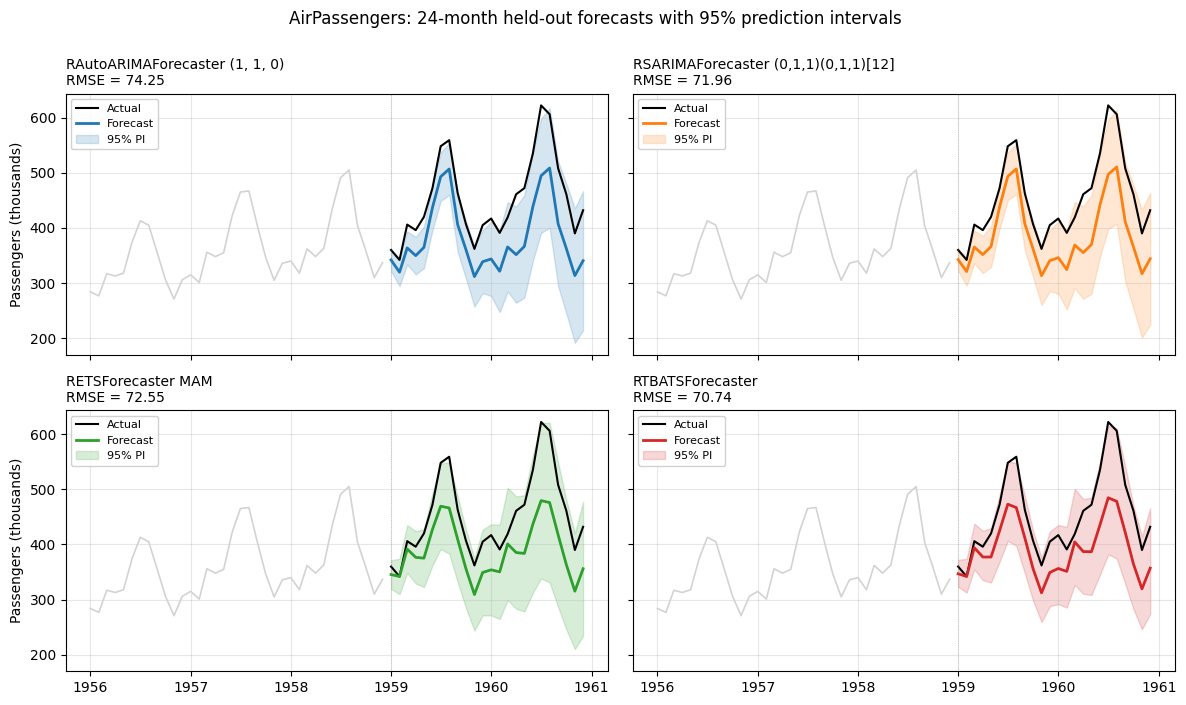

In [ ]:
import matplotlib.pyplot as plt

# Build the panel set from the same forecasters_holdout list
fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=True, sharey=True)
axes = axes.ravel()

# Show only the last 36 months of training context per panel
TRAIN_CONTEXT_MONTHS = 36
y_train_tail = y_train.iloc[-TRAIN_CONTEXT_MONTHS:]
split_date = y_test.index[0]

# Per-model color so each panel is visually distinct
panel_colors = ["C0", "C1", "C2", "C3"]

for ax, (name, model, fc), color in zip(
    axes, forecasters_holdout, panel_colors,
):
    # Training context (light gray, anchors "where forecast starts")
    ax.plot(y_train_tail.index, y_train_tail.values,
            color="lightgray", linewidth=1.2, label="_nolegend_")

    # Held-out actuals (solid black -- truth we are scoring against)
    ax.plot(y_test.index, y_test.values,
            color="black", linewidth=1.5, label="Actual")

    # Forecast point estimate
    ax.plot(fc.index, fc["forecast"].values,
            color=color, linewidth=2, label="Forecast")

    # 95% prediction interval band
    ax.fill_between(
        fc.index,
        fc["lower_95"].values, fc["upper_95"].values,
        color=color, alpha=0.18, label="95% PI",
    )

    # Vertical split line at train/test boundary
    ax.axvline(split_date, color="gray", linewidth=0.5,
               linestyle=":", alpha=0.6)

    # Per-panel title with held-out RMSE
    panel_rmse = rmse(y_test.values, fc["forecast"].values)
    ax.set_title(f"{name}\nRMSE = {panel_rmse:.2f}",
                 fontsize=10, loc="left")

    ax.grid(alpha=0.3)
    ax.legend(loc="upper left", fontsize=8, framealpha=0.9)

# y-axis labels only on the left column; x-axis tick labels handled
# by sharex/sharey
for i in (0, 2):
    axes[i].set_ylabel("Passengers (thousands)")

fig.suptitle(
    "AirPassengers: 24-month held-out forecasts with 95% prediction intervals",
    fontsize=12, y=1.00,
)
fig.tight_layout()
plt.show()

In [ ]:
# Synthetic monthly series: seasonal sine wave + regime-change step
np.random.seed(42)
n_train = 60
n_test = 12
n_total = n_train + n_test

t = np.arange(n_total)
seasonal = 5 * np.sin(2 * np.pi * t / 12)
trend = 0.05 * t
regime = np.where(t >= 36, 8.0, 0.0)  # step change at t=36
noise = np.random.normal(0, 0.5, n_total)
y_full = 20 + trend + seasonal + regime + noise

dates = pd.date_range("2020-01-01", periods=n_total, freq="MS")
y_xr = pd.Series(y_full, index=dates)
X_xr = pd.DataFrame({"regime": regime}, index=dates)

y_xr_train = y_xr.iloc[:n_train]
y_xr_test = y_xr.iloc[n_train:]
X_xr_train = X_xr.iloc[:n_train]
X_xr_test = X_xr.iloc[n_train:]

print(f"Synthetic series: {n_train} train + {n_test} test months")
print(f"Regime change happens at t=36 (in training data)")

# Fit with and without xreg using the same SARIMA order
m_no_xreg = RSARIMAForecaster(
    order=(1, 1, 1), seasonal_order=(0, 1, 1, 12),
).fit(y_xr_train)
m_with_xreg = RSARIMAForecaster(
    order=(1, 1, 1), seasonal_order=(0, 1, 1, 12),
).fit(y_xr_train, X=X_xr_train)

fc_no_xreg = m_no_xreg.forecast(steps=n_test)
fc_with_xreg = m_with_xreg.forecast(steps=n_test, X=X_xr_test)

print(f"\nIn-sample fit:")
print(f"  Without xreg: AIC = {m_no_xreg.aic_:.2f}")
print(f"  With xreg:    AIC = {m_with_xreg.aic_:.2f}  "
      f"(Δ = {m_no_xreg.aic_ - m_with_xreg.aic_:+.2f})")
print(f"\nHeld-out RMSE:")
print(f"  Without xreg: {rmse(y_xr_test.values, fc_no_xreg['forecast'].values):.3f}")
print(f"  With xreg:    {rmse(y_xr_test.values, fc_with_xreg['forecast'].values):.3f}")
print(f"\n(With xreg should both fit better in-sample and forecast "
      f"better out-of-sample, since the regime indicator is genuinely "
      f"informative.)")

Synthetic series: 60 train + 12 test months
Regime change happens at t=36 (in training data)

In-sample fit:
  Without xreg: AIC = 178.25
  With xreg:    AIC = 90.94  (Δ = +87.31)

Held-out RMSE:
  Without xreg: 2.470
  With xreg:    0.446

(With xreg should both fit better in-sample and forecast better out-of-sample, since the regime indicator is genuinely informative.)


In [ ]:
print("=== 5-fold expanding-window CV (test_size=12) on AirPassengers ===\n")

# We use the *full* AirPassengers series (not just y_train) because
# expanding-window CV uses the whole series, slicing internally.
cv_models = {
    "RAutoARIMAForecaster": RAutoARIMAForecaster(),
    "RSARIMAForecaster": RSARIMAForecaster(
        order=(0, 1, 1),
        seasonal_order=(0, 1, 1, 12),
    ),
    "RETSForecaster": RETSForecaster(model="ZZZ"),
    "RTBATSForecaster": RTBATSForecaster(),
}

print(f"{'Model':<32s}  {'CV RMSE':>10s}  {'std':>8s}")
print("-" * 54)
for name, model in cv_models.items():
    scores = forecaster_cv_score(
        model, air, n_splits=5, test_size=12, scoring="neg_rmse",
    )
    # neg_rmse returns negative values (sklearn convention: higher is better)
    cv_rmse = -scores
    print(f"{name:<32s}  {cv_rmse.mean():>10.2f}  {cv_rmse.std():>8.2f}")

# Show what forecaster_cv (the richer version) returns
print("\n=== forecaster_cv: per-fold per-step DataFrame ===\n")
cv_detail = forecaster_cv(
    RSARIMAForecaster(order=(0, 1, 1), seasonal_order=(0, 1, 1, 12)),
    air, n_splits=3, test_size=12,
)
print(f"Shape: {cv_detail.shape}  (3 folds * 12 steps = 36 rows)")
print(f"\nFirst fold, first 5 steps:")
print(cv_detail.head().round(2))

# Quick sanity check
print(f"\nMean residual across all folds/steps: "
      f"{cv_detail['residual'].mean():.3f}")
print(f"Std residual: {cv_detail['residual'].std():.3f}")

=== 5-fold expanding-window CV (test_size=12) on AirPassengers ===

Model                                CV RMSE       std
------------------------------------------------------
RAutoARIMAForecaster                   23.84     12.74
RSARIMAForecaster                      23.04     12.26
RETSForecaster                         28.13     11.87
RTBATSForecaster                       24.70     13.82

=== forecaster_cv: per-fold per-step DataFrame ===

Shape: (36, 5)  (3 folds * 12 steps = 36 rows)

First fold, first 5 steps:
   fold  step  actual  forecast  residual
0     0     1   340.0    346.08     -6.08
1     0     2   318.0    332.90    -14.90
2     0     3   362.0    385.98    -23.98
3     0     4   348.0    378.55    -30.55
4     0     5   363.0    385.25    -22.25

Mean residual across all folds/steps: 4.674
Std residual: 31.903


# Section 5: Mixed Effects Models

In [ ]:
"""
RGLMM: generalized linear mixed-effects models via R's glmmTMB.

Different shape from the GLM/classifier classes: takes (data, formula)
at fit() time rather than (X, y), because random-effects structure
in the formula references columns that aren't predictors in the
sklearn sense (grouping factors).

Supports zero-inflation via the ziformula parameter and exposes the
ZI coefficients and random-effects correlation matrices as fitted
attributes.

Inherits from BaseEstimator (so clone, get_params, set_params work)
but NOT from RegressorMixin -- score(data, y) would have a confusing
signature given that data already contains y.
"""


GLMM_FAMILIES = {
    "gaussian":  "stats::gaussian()",
    "binomial":  "stats::binomial()",
    "poisson":   "stats::poisson()",
    "Gamma":     'stats::Gamma(link = "log")',
    "nbinom1":   "glmmTMB::nbinom1()",
    "nbinom2":   "glmmTMB::nbinom2()",
    "tweedie":   "glmmTMB::tweedie()",
    "beta":      "glmmTMB::beta_family()",
}


class RGLMM(BaseEstimator):
    """
    Generalized linear mixed-effects model via R's glmmTMB::glmmTMB.

    Parameters
    ----------
    family : str, default "gaussian"
        One of: gaussian, binomial, poisson, Gamma, nbinom1, nbinom2,
        tweedie, beta.
    ziformula : str, optional
        Zero-inflation formula. Default None means no zero-inflation
        component. Examples:
          * "~1"        -- intercept-only ZI (constant zero-inflation
                           probability across all observations)
          * "~X1"       -- ZI probability depends on predictor X1
          * "~X1+X2"    -- ZI depends on multiple predictors
        When set, glmmTMB fits a two-part model: the conditional model
        (the chosen family) for non-structural-zero observations, and
        a logistic model for the probability of being a structural zero.
    REML : bool, default False
        Restricted maximum likelihood. Default False (full ML) gives
        likelihood-comparable AIC/BIC across nested models.

    Fitted Attributes (set after fit() returns)
    -------------------------------------------
    formula_ : str
    family_ : str
    has_zero_inflation_ : bool
        Whether the model includes a ZI component.
    coefficients_ : pandas.DataFrame
        Conditional-model fixed effects (Estimate, Std. Error, z value,
        Pr(>|z|)).
    zi_coefficients_ : pandas.DataFrame or None
        Zero-inflation model fixed effects, same column structure as
        coefficients_. None if ziformula was not passed.
    random_effects_var_ : pandas.DataFrame
        Diagonal-only variance components per (group, term).
        Columns: group, term, variance, std_dev.
    random_effects_corr_ : dict[str, pandas.DataFrame]
        Full correlation matrix per grouping factor. For groups with
        a single random term (e.g. (1|group)), this is the trivial
        1x1 matrix [[1.0]]. For groups with multiple random terms
        (e.g. (1+Days|Subject)), gives the correlation matrix
        between those terms.
    aic_, bic_ : float
    llf_ : float
        Log-likelihood of the fitted model.
    n_obs_ : int
    converged_ : bool
    r_object_ : rpy2 object
        The fitted glmmTMB object.

    Notes
    -----
    Requires the glmmTMB R package.
    """

    _required_r_package = "glmmTMB"

    def __init__(
        self,
        family: str = "gaussian",
        ziformula: Optional[str] = None,
        REML: bool = False,
    ):
        self.family = family
        self.ziformula = ziformula
        self.REML = REML

    def fit(self, data: pd.DataFrame, formula: str):
        """
        Fit the GLMM.

        Parameters
        ----------
        data : pandas.DataFrame
            Long-format dataframe containing response, predictors,
            and grouping columns referenced in the formula.
        formula : str
            A glmmTMB-style formula, e.g.
            "Reaction ~ Days + (1+Days|Subject)".
        """
        self._check_r_package_available()

        if self.family not in GLMM_FAMILIES:
            raise ValueError(
                f"family must be one of {sorted(GLMM_FAMILIES)}; "
                f"got {self.family!r}"
            )
        if not isinstance(data, pd.DataFrame):
            raise TypeError(
                f"data must be a pandas.DataFrame; got "
                f"{type(data).__name__}"
            )
        if len(data) < 2:
            raise ValueError(
                f"data must have at least 2 rows; got {len(data)}"
            )

        self.formula_ = formula
        self.family_ = self.family
        self.n_obs_ = len(data)
        self.has_zero_inflation_ = self.ziformula is not None

        self._push_dataframe(data, R_GLMM_DATA)

        family_expr = GLMM_FAMILIES[self.family]
        ziformula_arg = ""
        if self.has_zero_inflation_:
            ziformula_arg = f", ziformula = {self.ziformula}"

        ro.r(f"""
            {R_MODEL} <- glmmTMB::glmmTMB(
                {self.formula_},
                data   = {R_GLMM_DATA},
                family = {family_expr}{ziformula_arg},
                REML   = {'TRUE' if self.REML else 'FALSE'}
            )
        """)

        self.r_object_ = ro.globalenv[R_MODEL]
        self._extract_fitted_attributes()
        return self

    def predict(
        self,
        newdata: pd.DataFrame,
        re_form: Optional[str] = None,
        type: str = "response",
    ) -> np.ndarray:
        """
        Predict on new data.

        Parameters
        ----------
        newdata : pandas.DataFrame
            New data, with the same columns as the training data
            (including grouping columns referenced by random effects).
        re_form : str, optional
            Random-effects formula passed to glmmTMB's re.form=.
            None (default) uses fitted random effects (unit-level).
            "NA" gives population-level prediction (no random effects).
        type : str, default "response"
            Prediction scale: "response", "link", "conditional", or
            "zprob" (zero-probability for ZI models).
        """
        check_is_fitted(self, "r_object_")
        if not isinstance(newdata, pd.DataFrame):
            raise TypeError(
                f"newdata must be a pandas.DataFrame; got "
                f"{type(newdata).__name__}"
            )

        ro.globalenv[R_MODEL] = self.r_object_
        self._push_dataframe(newdata, R_GLMM_NEWDATA)

        re_form_arg = ""
        if re_form is not None:
            if re_form == "NA":
                re_form_arg = ", re.form = NA"
            else:
                re_form_arg = f", re.form = {re_form}"

        return r_to_numpy(ro.r(
            f'predict({R_MODEL}, newdata = {R_GLMM_NEWDATA}, '
            f'type = "{type}"{re_form_arg})'
        )).ravel()

    def random_effects(self) -> dict:
        """
        Return BLUPs (conditional modes) of the random effects as a
        dict mapping grouping factor name -> pandas.DataFrame of
        per-level random-effect estimates.

        Equivalent to glmmTMB::ranef(model)$cond in R.
        """
        check_is_fitted(self, "r_object_")
        ro.globalenv[R_MODEL] = self.r_object_

        ranef_obj = ro.r(f"glmmTMB::ranef({R_MODEL})$cond")
        result = {}
        for grp in list(ranef_obj.names):
            mat = r_to_numpy(ro.r(
                f"as.matrix(glmmTMB::ranef({R_MODEL})$cond$`{grp}`)"
            ))
            row_names = list(ro.r(
                f"rownames(glmmTMB::ranef({R_MODEL})$cond$`{grp}`)"
            ))
            col_names = list(ro.r(
                f"colnames(glmmTMB::ranef({R_MODEL})$cond$`{grp}`)"
            ))
            result[grp] = pd.DataFrame(
                mat, index=row_names, columns=col_names,
            )
        return result

    def summary(self) -> str:
        check_is_fitted(self, "r_object_")
        ro.globalenv[R_MODEL] = self.r_object_
        return str(ro.r(
            f'paste(capture.output(print(summary({R_MODEL}))), '
            f'collapse = "\\n")'
        )[0])

    def run_r(self, code: str):
        check_is_fitted(self, "r_object_")
        ro.globalenv[R_MODEL] = self.r_object_
        return ro.r(code)

    # ------------------------------------------------------------------ #
    # Internals
    # ------------------------------------------------------------------ #
    def _check_r_package_available(self) -> None:
        from rpy2.robjects.packages import isinstalled
        if not isinstalled(self._required_r_package):
            raise RuntimeError(
                f"RGLMM requires R package "
                f"{self._required_r_package!r}, which is not "
                f"installed. Install via: env.install(["
                f"{self._required_r_package!r}])"
            )

    @staticmethod
    def _push_dataframe(df: pd.DataFrame, r_name: str) -> None:
        with localconverter(default_converter + pandas2ri.converter):
            r_df = ro.conversion.py2rpy(df)
        ro.globalenv[r_name] = r_df

    def _extract_fitted_attributes(self) -> None:
        # --- Conditional-model fixed effects ---
        coef_matrix = r_to_numpy(
            ro.r(f"summary({R_MODEL})$coefficients$cond")
        )
        coef_rownames = list(
            ro.r(f"rownames(summary({R_MODEL})$coefficients$cond)")
        )
        coef_colnames = list(
            ro.r(f"colnames(summary({R_MODEL})$coefficients$cond)")
        )
        self.coefficients_ = pd.DataFrame(
            coef_matrix, index=coef_rownames, columns=coef_colnames,
        )

        # --- ZI fixed effects (only if ZI was fit) ---
        if self.has_zero_inflation_:
            zi_matrix = r_to_numpy(
                ro.r(f"summary({R_MODEL})$coefficients$zi")
            )
            zi_rownames = list(
                ro.r(f"rownames(summary({R_MODEL})$coefficients$zi)")
            )
            zi_colnames = list(
                ro.r(f"colnames(summary({R_MODEL})$coefficients$zi)")
            )
            self.zi_coefficients_ = pd.DataFrame(
                zi_matrix, index=zi_rownames, columns=zi_colnames,
            )
        else:
            self.zi_coefficients_ = None

        # --- Random-effects variances and correlations ---
        # VarCorr(model)$cond is a list of covariance matrices, one per
        # grouping factor. Each matrix has variances on the diagonal
        # and covariances off-diagonal. We extract both the diagonal-
        # only flat variance table and the per-group correlation matrix.
        var_rows = []
        corr_dict = {}
        groups = list(ro.r(f"names(glmmTMB::VarCorr({R_MODEL})$cond)"))
        for grp in groups:
            term_names = list(ro.r(
                f'colnames(glmmTMB::VarCorr({R_MODEL})$cond$`{grp}`)'
            ))
            covmat = r_to_numpy(ro.r(
                f'glmmTMB::VarCorr({R_MODEL})$cond$`{grp}`'
            ))
            for i, term in enumerate(term_names):
                var = float(covmat[i, i])
                var_rows.append({
                    "group":    grp,
                    "term":     term,
                    "variance": var,
                    "std_dev":  np.sqrt(var),
                })
            # Correlation matrix: cov_ij / (sd_i * sd_j)
            sds = np.sqrt(np.diag(covmat))
            with np.errstate(invalid="ignore", divide="ignore"):
                corr_mat = covmat / np.outer(sds, sds)
                # Replace NaN/inf (from zero variances) with 0 and
                # reset diagonal to 1
                corr_mat = np.where(
                    np.isfinite(corr_mat), corr_mat, 0.0,
                )
                np.fill_diagonal(corr_mat, 1.0)
            corr_dict[grp] = pd.DataFrame(
                corr_mat, index=term_names, columns=term_names,
            )
        self.random_effects_var_ = pd.DataFrame(var_rows)
        self.random_effects_corr_ = corr_dict

        # --- Scalar metrics ---
        self.aic_ = float(ro.r(f"AIC({R_MODEL})")[0])
        self.bic_ = float(ro.r(f"BIC({R_MODEL})")[0])
        self.llf_ = float(ro.r(f"as.numeric(logLik({R_MODEL}))")[0])

        try:
            conv = int(ro.r(f"{R_MODEL}$fit$convergence")[0])
            self.converged_ = (conv == 0)
        except Exception:
            self.converged_ = True

print(f"Available families: {sorted(GLMM_FAMILIES)}")

Available families: ['Gamma', 'beta', 'binomial', 'gaussian', 'nbinom1', 'nbinom2', 'poisson', 'tweedie']


In [ ]:
# sleepstudy pulled from lme4
ro.r("data(sleepstudy, package = 'lme4')")
sleepstudy = r_to_dataframe("sleepstudy")
sleepstudy["Subject"] = sleepstudy["Subject"].astype(str)

print(f"sleepstudy: {sleepstudy.shape}")
print(sleepstudy.head())
print(f"\n{sleepstudy['Subject'].nunique()} subjects, "
      f"{sleepstudy.groupby('Subject').size().iloc[0]} days each")
print(f"Reaction range: {sleepstudy['Reaction'].min():.0f}-"
      f"{sleepstudy['Reaction'].max():.0f} ms")

# Fit the canonical model: random intercept + slope per subject
sleep_model = RGLMM().fit(
    sleepstudy,
    formula="Reaction ~ Days + (1 + Days | Subject)",
)

print(f"\n=== Fixed effects ===")
print(sleep_model.coefficients_.round(3))

print(f"\n=== Random-effects variances ===")
print(sleep_model.random_effects_var_.round(3))

print(f"\n=== Model fit ===")
print(f"AIC:       {sleep_model.aic_:.2f}")
print(f"BIC:       {sleep_model.bic_:.2f}")
print(f"logLik:    {sleep_model.llf_:.2f}")
print(f"Converged: {sleep_model.converged_}")

sleepstudy: (180, 3)
   Reaction  Days Subject
1  249.5600   0.0     308
2  258.7047   1.0     308
3  250.8006   2.0     308
4  321.4398   3.0     308
5  356.8519   4.0     308

18 subjects, 10 days each
Reaction range: 194-466 ms

=== Fixed effects ===
             Estimate  Std. Error  z value  Pr(>|z|)
(Intercept)   251.404       6.632   37.907       0.0
Days           10.467       1.502    6.968       0.0

=== Random-effects variances ===
     group         term  variance  std_dev
0  Subject  (Intercept)   565.491   23.780
1  Subject         Days    32.681    5.717

=== Model fit ===
AIC:       1763.94
BIC:       1783.10
logLik:    -875.97
Converged: True


In [ ]:
# With the (1 + Days | Subject) random-effects structure, we get a 2x2
# correlation matrix between the per-subject intercept deviation and
# the per-subject slope deviation. The off-diagonal tells us whether
# fast-baseline subjects also slow down faster (positive) or slower
# (negative) under sleep deprivation.

print("=== Random-effects correlation matrix per group ===\n")
for grp_name, corr_df in sleep_model.random_effects_corr_.items():
    print(f"Grouping factor: {grp_name}")
    print(corr_df.round(3))
    print()

=== Random-effects correlation matrix per group ===

Grouping factor: Subject
             (Intercept)   Days
(Intercept)        1.000  0.081
Days               0.081  1.000



In [ ]:
# random_effects() returns the BLUPs -- the per-subject conditional
# modes, i.e. each subject's individual deviation from the population-
# average intercept and slope. These shrink toward zero relative to
# what you'd get from per-subject OLS fits.

blups = sleep_model.random_effects()
print(f"random_effects() returned a dict with keys: {list(blups.keys())}\n")

subject_blups = blups["Subject"]
print(f"=== Per-subject BLUPs (first 6 subjects) ===")
print(subject_blups.head(6).round(2))

# Predict at unit level (using fitted random effects) vs population
# level (random effects set to zero -- this is what you'd predict for
# a new subject not in the training data).
preds_unit = sleep_model.predict(sleepstudy)
preds_pop  = sleep_model.predict(sleepstudy, re_form="NA")

print(f"\n=== Unit-level vs population-level prediction ===")
print(f"Unit-level (uses subject's own BLUPs):")
print(f"  mean prediction: {preds_unit.mean():.1f} ms")
print(f"  prediction var:  {preds_unit.var():.1f}")
print(f"  RMSE vs actual:  "
      f"{np.sqrt(np.mean((preds_unit - sleepstudy['Reaction'])**2)):.1f}")

print(f"\nPopulation-level (re_form='NA', no random effects):")
print(f"  mean prediction: {preds_pop.mean():.1f} ms")
print(f"  prediction var:  {preds_pop.var():.1f}")
print(f"  RMSE vs actual:  "
      f"{np.sqrt(np.mean((preds_pop - sleepstudy['Reaction'])**2)):.1f}")

print(f"\n(Population-level prediction has lower variance -- it's the "
      f"average response trajectory across all subjects -- and higher "
      f"RMSE, since it can't use individual subject information.)")

random_effects() returned a dict with keys: ['Subject']

=== Per-subject BLUPs (first 6 subjects) ===
     (Intercept)  Days
308         2.82  9.08
309       -40.05 -8.64
310       -38.43 -5.51
330        22.83 -4.66
331        21.55 -2.94
332         8.82 -0.24

=== Unit-level vs population-level prediction ===
Unit-level (uses subject's own BLUPs):
  mean prediction: 298.5 ms
  prediction var:  2397.8
  RMSE vs actual:  23.5

Population-level (re_form='NA', no random effects):
  mean prediction: 298.5 ms
  prediction var:  903.9
  RMSE vs actual:  47.4

(Population-level prediction has lower variance -- it's the average response trajectory across all subjects -- and higher RMSE, since it can't use individual subject information.)


In [ ]:
# Generate synthetic zero-inflated count data
# 30 sites x 8 visits = 240 observations
np.random.seed(0)

n_sites = 30
n_visits = 8
sites = np.repeat(np.arange(n_sites), n_visits)
habitat = np.repeat(
    np.array(["A"] * (n_sites // 2) + ["B"] * (n_sites // 2)),
    n_visits,
)
temperature = np.random.uniform(10, 30, size=n_sites * n_visits)

# Structural-zero probability: 10% for habitat A, 70% for habitat B
zi_prob = np.where(habitat == "A", 0.10, 0.70)
is_structural_zero = np.random.binomial(1, zi_prob).astype(bool)

# Conditional Poisson mean: depends on temperature, with site-level
# random intercept
site_intercept = np.random.normal(0, 0.3, n_sites)
log_mu = 1.5 + 0.05 * temperature + site_intercept[sites]
mu = np.exp(log_mu)

# Observed count: zero if structural zero, else Poisson(mu)
count = np.where(
    is_structural_zero,
    0,
    np.random.poisson(mu),
)

zi_data = pd.DataFrame({
    "count":       count,
    "temperature": temperature,
    "habitat":     habitat,
    "site":        [f"S{s:02d}" for s in sites],
})

print(f"ZI dataset: {len(zi_data)} observations across {n_sites} sites")
print(f"Overall zero rate: {(zi_data['count'] == 0).mean():.2%}")
hab_a_zero = (zi_data.query('habitat == "A"')['count'] == 0).mean()
hab_b_zero = (zi_data.query('habitat == "B"')['count'] == 0).mean()
print(f"  habitat A: {hab_a_zero:.2%}")
print(f"  habitat B: {hab_b_zero:.2%}")

# Fit a Poisson GLMM with no zero-inflation first, for baseline AIC
m_poi_only = RGLMM(family="poisson").fit(
    zi_data,
    formula="count ~ temperature + (1|site)",
)

# Fit a zero-inflated Poisson GLMM. The ziformula models the structural
# zero probability as a function of habitat: we expect habitat B to
# have a much higher coefficient.
m_zip = RGLMM(
    family="poisson",
    ziformula="~habitat",
).fit(
    zi_data,
    formula="count ~ temperature + (1|site)",
)

print("\n=== Model comparison (lower AIC is better) ===")
print(f"Poisson GLMM (no ZI):       AIC = {m_poi_only.aic_:.1f}")
print(f"Zero-inflated Poisson GLMM: AIC = {m_zip.aic_:.1f}")
print(f"AIC reduction from adding ZI: "
      f"{m_poi_only.aic_ - m_zip.aic_:.1f}")

ZI dataset: 240 observations across 30 sites
Overall zero rate: 39.17%
  habitat A: 11.67%
  habitat B: 66.67%

=== Model comparison (lower AIC is better) ===
Poisson GLMM (no ZI):       AIC = 2164.1
Zero-inflated Poisson GLMM: AIC = 1066.9
AIC reduction from adding ZI: 1097.2


In [ ]:
print("=== Conditional-model coefficients (Poisson, count|present) ===")
print(m_zip.coefficients_.round(3))

print("\n=== Zero-inflation coefficients (logit P(structural zero)) ===")
print(m_zip.zi_coefficients_.round(3))

# The ZI intercept is the log-odds of structural zero for habitat A
# (the reference level). The habitatB coefficient is the log-odds
# shift for habitat B vs A. Convert to probabilities to recover the
# true 10% / 70% generating values:
zi_intercept = m_zip.zi_coefficients_.loc["(Intercept)", "Estimate"]
zi_habitatB  = m_zip.zi_coefficients_.loc["habitatB", "Estimate"]

p_zi_A = 1 / (1 + np.exp(-zi_intercept))
p_zi_B = 1 / (1 + np.exp(-(zi_intercept + zi_habitatB)))

print(f"\nImplied structural-zero probabilities:")
print(f"  habitat A: {p_zi_A:.2%}  (true was 10%)")
print(f"  habitat B: {p_zi_B:.2%}  (true was 70%)")

# Sanity check: zi_coefficients_ is None for non-ZI models
print(f"\nm_poi_only.zi_coefficients_ is None: "
      f"{m_poi_only.zi_coefficients_ is None}")
print(f"m_zip.zi_coefficients_ is a DataFrame: "
      f"{isinstance(m_zip.zi_coefficients_, pd.DataFrame)}")

=== Conditional-model coefficients (Poisson, count|present) ===
             Estimate  Std. Error  z value  Pr(>|z|)
(Intercept)     1.496       0.113   13.203       0.0
temperature     0.048       0.005   10.407       0.0

=== Zero-inflation coefficients (logit P(structural zero)) ===
             Estimate  Std. Error  z value  Pr(>|z|)
(Intercept)    -2.026       0.285   -7.113       0.0
habitatB        2.719       0.344    7.893       0.0

Implied structural-zero probabilities:
  habitat A: 11.65%  (true was 10%)
  habitat B: 66.66%  (true was 70%)

m_poi_only.zi_coefficients_ is None: True
m_zip.zi_coefficients_ is a DataFrame: True


=== DHARMa diagnostics on the ZIP-GLMM ===

Uniformity p-value: 0.7485  (should be > 0.05 if model is well-specified)
Dispersion p-value: 0.5800
Outlier p-value:    1.0000

=== DHARMa diagnostics on the no-ZI Poisson GLMM ===

Uniformity p-value: 0.0000
Dispersion p-value: 0.8040
Outlier p-value:    1.0000

(The no-ZI model should show worse uniformity and/or dispersion p-values, since it's misspecified for this data.)

=== DHARMa plot for the ZIP-GLMM ===


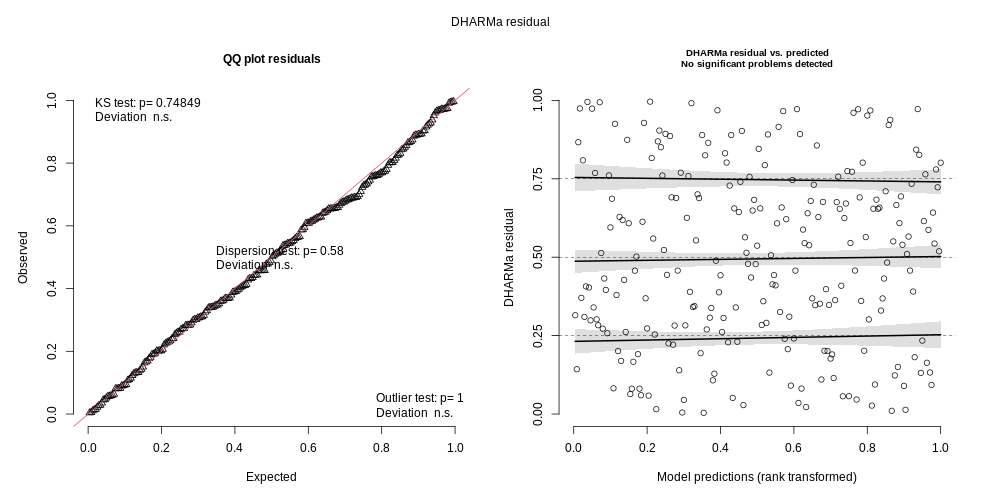


=== DHARMa plot for the no-ZI Poisson GLMM ===


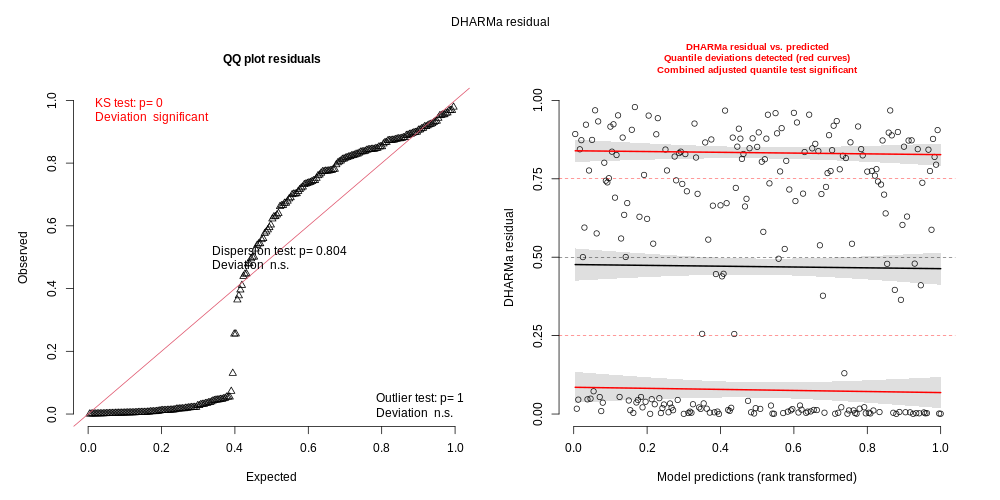

In [ ]:
# The DHARMa diagnostics
print("=== DHARMa diagnostics on the ZIP-GLMM ===\n")
dh_zip = dharma_diagnostics(
    m_zip,
    n_sim=500,
    seed=42,
    plot=True,
    plot_path="/tmp/dharma_zip.png"
)
print(f"Uniformity p-value: {dh_zip['uniformity_pvalue']:.4f}  "
      f"(should be > 0.05 if model is well-specified)")
print(f"Dispersion p-value: {dh_zip['dispersion_pvalue']:.4f}")
print(f"Outlier p-value:    {dh_zip['outlier_pvalue']:.4f}")

# Compare with the no-ZI model's diagnostics -- should look worse
print("\n=== DHARMa diagnostics on the no-ZI Poisson GLMM ===\n")
dh_poi = dharma_diagnostics(
    m_poi_only,
    n_sim=500,
    seed=42,
    plot=True,
    plot_path="/tmp/dharma_poi.png"
)
print(f"Uniformity p-value: {dh_poi['uniformity_pvalue']:.4f}")
print(f"Dispersion p-value: {dh_poi['dispersion_pvalue']:.4f}")
print(f"Outlier p-value:    {dh_poi['outlier_pvalue']:.4f}")

print("\n(The no-ZI model should show worse uniformity and/or "
      "dispersion p-values, since it's misspecified for this data.)")

from IPython.display import Image, display
print(f"\n=== DHARMa plot for the ZIP-GLMM ===")
display(Image(dh_zip["plot_path"]))

print(f"\n=== DHARMa plot for the no-ZI Poisson GLMM ===")
display(Image(dh_poi["plot_path"]))